<a href="https://colab.research.google.com/github/AakashK-17/Aakash1702/blob/main/MRC_WorkSample_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MRC Work Sample Analysis 2026
**Analyst:** Aakash Kunarapu  
**Date:** April 2026  
**Environment:** Google Colab + Google Drive

### Background
This analysis uses data from a mental health program serving children and teenagers.
The program collects three types of data per client:

- **YOQ** (Youth Outcome Questionnaire): Parent-reported mental health assessment.
  Higher score = more impaired. Score above 46 = clinical distress territory.
- **Demographics**: Age, gender, and ethnicity of each client.
- **PEARLS**: Adverse Childhood Experiences (ACEs) score. Range 0–10.
  Higher = more childhood trauma exposure.

### Goal
Answer 6 research questions about client demographics,
trauma burden, and program outcomes Python.

### Data Source
Excel file with 4 sheets: Notes, YOQ, Demographics, PEARLS.
All sheets contain 6,792 rows representing 3,012 unique patients.

In [ ]:
import pandas as pd

excel_file_path = '/content/drive/MyDrive/datasets/Work Sample Data 2026.xlsx'

# Read the Excel file, specifying that it has multiple sheets
x = pd.ExcelFile(excel_file_path)

# Load all sheets into a dictionary of DataFrames
df_dict = {}
for sheet_name in x.sheet_names:
    df_dict[sheet_name] = x.parse(sheet_name)

print(f"Successfully loaded Excel file with the following sheets: {list(df_dict.keys())}")

# You can access individual sheets like this:
# df_sheet1 = df_dict['Sheet1']
# df_sheet2 = df_dict['Sheet2']

Successfully loaded Excel file with the following sheets: ['Notes', 'YOQ', 'Demographics', 'PEARLS']


In [ ]:
yoq    = df_dict["YOQ"]
demo   = df_dict["Demographics"]
pearls = df_dict["PEARLS"]

print(yoq.head())
print(demo.head())
print(pearls.head())

  PatientID  ClinicianID LocationName YOQAdministrationDate  TotalYOQScore
0        14         1322     Clinic G            2021-03-29             68
1        25         1142     Clinic G            2020-05-18             89
2        28          854     Clinic G            2021-04-28             33
3        28          854     Clinic G            2020-12-22            133
4       184         1420     Clinic C            2021-01-13             21
  PatientID Gender  AgeYears                 Ethnicity
0     25683      F        18                   Mexican
1     25687      F         9  Caucasian/European/White
2     25688      F        11                       NaN
3     25688      F        11                       NaN
4     25689      F        15                     Other
  PatientID  ACEsScore
0     25683        1.0
1     25687        NaN
2     25688        NaN
3     25688        NaN
4     25689        1.0


### Task 2: Explore the Data - Shape and Missing Values

Before touching any data we need to understand what we have.
Two things we check here:

**Shape** - confirms the data loaded correctly.
We expect all three tables to have 6,792 rows but only 3,012
unique patients, meaning patients appear multiple times
across different assessment sessions.

**Missing Values** - identifies gaps we must handle later.
Missing data silently distorts results if ignored.
For example, if we calculate average ACEs without accounting
for missing values, we get a wrong number.

What we expect to find:
- YOQ: 1 missing LocationName → not important, won't affect analysis
- Demographics: 14 missing Gender, 150 missing Ethnicity → affects group comparisons
- PEARLS: 562 missing ACEsScore → significant, many clients have no ACEs data recorded

In [ ]:
# Check shape of each dataset
print(yoq.shape)
print(demo.shape)
print(pearls.shape)

# Check missing values
print(yoq.isnull().sum())
print(demo.isnull().sum())
print(pearls.isnull().sum())

(6792, 5)
(6792, 4)
(6792, 2)
PatientID                0
ClinicianID              0
LocationName             1
YOQAdministrationDate    0
TotalYOQScore            0
dtype: int64
PatientID      0
Gender        14
AgeYears       0
Ethnicity    150
dtype: int64
PatientID      0
ACEsScore    562
dtype: int64


### Task 3: Fix the Date Column

When pandas reads an Excel file, date columns sometimes load
as plain text or a generic "object" type. Python sees
"2021-03-29" as just a string of characters - like a word -
not as an actual calendar date.

If the date column stays as text we cannot:
- Sort patients by their earliest and latest assessment
- Compare two dates to check if they are the same day
- Find which assessment came first and which came last

We convert YOQAdministrationDate to datetime64 format so
Python treats it as a real date and can perform date operations.

How to verify it worked:
- dtype should show datetime64[ns] - confirms conversion succeeded
- head() should show clean YYYY-MM-DD formatted dates

Your output confirms both - datetime64[ns] with clean dates.
This step unlocks everything in Task 4 onwards.

In [ ]:
# Fix date column
yoq["YOQAdministrationDate"] = pd.to_datetime(yoq["YOQAdministrationDate"])

# Verify it worked
print(yoq["YOQAdministrationDate"].dtype)
print(yoq["YOQAdministrationDate"].head())

datetime64[ns]
0   2021-03-29
1   2020-05-18
2   2021-04-28
3   2020-12-22
4   2021-01-13
Name: YOQAdministrationDate, dtype: datetime64[ns]


### Task 4: Find First and Last YOQ Score Per Patient

From Task 2 we know YOQ has 6,792 rows but only 3,012 unique
patients. That means each patient has multiple assessment rows -
one per clinic visit. We cannot measure change using all rows
mixed together. We need exactly two data points per patient:

- **First assessment** → baseline, how impaired the child was
  when they entered the program
- **Last assessment** → outcome, how impaired the child was
  at their most recent visit

Steps:
1. Sort entire YOQ table by PatientID then by date — so each
   patient's rows are in chronological order
2. Group by PatientID and take the FIRST row → earliest date
3. Group by PatientID and take the LAST row → latest date
4. Merge first and last side by side - one row per patient

What to watch for in the output:
- Shape should be (3,012 x 5) - one row per patient ✓
- Some patients will have the SAME FirstDate and LastDate
  (like PatientID 14 and 198 above) - these will be excluded
  in the next task as they cannot produce a valid change score
- Some patients like PatientID 28 show very different scores
  (FirstYOQ 133 → LastYOQ 33) - a dramatic improvement of 100 points

In [ ]:
# Sort by patient and date
yoq_sorted = yoq.sort_values(["PatientID", "YOQAdministrationDate"])

# First assessment per patient
yoq_first = (yoq_sorted
    .groupby("PatientID")
    .first()
    .reset_index()
    [["PatientID", "YOQAdministrationDate", "TotalYOQScore"]]
    .rename(columns={"YOQAdministrationDate": "FirstDate",
                     "TotalYOQScore": "FirstYOQ"}))

# Last assessment per patient
yoq_last = (yoq_sorted
    .groupby("PatientID")
    .last()
    .reset_index()
    [["PatientID", "YOQAdministrationDate", "TotalYOQScore"]]
    .rename(columns={"YOQAdministrationDate": "LastDate",
                     "TotalYOQScore": "LastYOQ"}))

# Combine first and last
yoq_scores = yoq_first.merge(yoq_last, on="PatientID")

print(yoq_scores.head())
print(yoq_scores.shape)

  PatientID  FirstDate  FirstYOQ   LastDate  LastYOQ
0        14 2021-03-29        68 2021-03-29       68
1        25 2020-05-18        89 2020-05-18       89
2        28 2020-12-22       133 2021-04-28       33
3       184 2019-12-04        78 2021-01-13       21
4       198 2021-01-25        68 2021-01-25       68
(3012, 5)


### Task 5: Calculate Change Score + Data Cleaning

Now that we have first and last scores per patient we can
calculate how much each child changed over the course of treatment.

**Change Score Formula:**
ChangeScore = LastYOQ - FirstYOQ

- Negative value = improvement (score went DOWN = less impaired)
- Positive value = got worse (score went UP = more impaired)
- Zero = no change

**Data Cleaning Rule (from assignment instructions):**
If a patient's FirstDate and LastDate are the SAME date, exclude them.
Same-day first and last means either:
- The patient only came once and has no follow-up, OR
- Their data was entered twice on the same day in error
Neither case gives us a meaningful measure of change over time.

Before cleaning: 3,012 patients
After cleaning:  1,629 patients (1,383 excluded as same-date)

**What the change score statistics tell us:**
- Mean of -17.4 → on average patients improved
- Median of -16.0 → the typical patient got meaningfully better
- Min of -157 → one patient improved dramatically
- Max of +107 → one patient got significantly worse
- 75th percentile is +2.0 → three quarters of patients
  either improved or stayed roughly the same

In [ ]:
# Remove same-date cases - not valid change measurements
yoq_scores = yoq_scores[yoq_scores["FirstDate"] != yoq_scores["LastDate"]]

# Calculate change score
# Negative = improvement (score went down = less impairment)
# Positive = got worse (score went up = more impairment)
yoq_scores["ChangeScore"] = yoq_scores["LastYOQ"] - yoq_scores["FirstYOQ"]

print("Clients remaining after cleaning:", yoq_scores.shape[0])
print(yoq_scores["ChangeScore"].describe())
print(yoq_scores.head())

Clients remaining after cleaning: 1629
count    1629.000000
mean      -17.387354
std        32.551382
min      -157.000000
25%       -36.000000
50%       -16.000000
75%         2.000000
max       107.000000
Name: ChangeScore, dtype: float64
  PatientID  FirstDate  FirstYOQ   LastDate  LastYOQ  ChangeScore
2        28 2020-12-22       133 2021-04-28       33         -100
3       184 2019-12-04        78 2021-01-13       21          -57
7       499 2019-08-09       145 2021-04-17      163           18
8       527 2019-07-30        53 2020-09-29       69           16
9       560 2019-07-26         5 2020-10-26       49           44


### Task 6: Merge All Three Datasets

We now have three separate tables. The research questions need
variables from all three simultaneously - for example, question 5d
asks how ACEs differ by gender and ethnicity, which requires
demographics and PEARLS in the same row.

We need one unified dataset with every variable per patient.

**Two preparation steps before merging:**

1. Demographics has duplicate rows per patient - we saw PatientID
   25688 appear twice in Task 1. We use drop_duplicates to keep
   only one row per patient before merging.

2. PEARLS can have multiple ACEs scores per patient across
   different sessions. Per the assignment instructions:
   once an ACE occurs it cannot be undone, so we take the
   MAXIMUM ACEs score per patient as their true ACE burden.

**Merge strategy - LEFT JOIN on PatientID:**
We use a left join starting from demographics so all 3,012
patients are retained even if they have no YOQ change score
or no ACEs data recorded.

**Why so many NaN values in the merged table:**
Patients like PatientID 25683 show NaN for FirstDate, FirstYOQ,
ChangeScore - this is expected and correct. These patients were
excluded in Task 5 because they had only one assessment or
same-date entries. They still exist in demographics but have
no YOQ change data. The left join correctly keeps them but
leaves YOQ columns blank.

Expected result: (3,012 rows × 10 columns) ✓

In [ ]:
# Step 1: Max ACEs per patient
# Why max: once an ACE happens it cannot be undone
# If a patient has multiple PEARLS records take the worst one
pearls_max = (pearls
    .groupby("PatientID")["ACEsScore"]
    .max()
    .reset_index()
    .rename(columns={"ACEsScore": "MaxACEs"}))

print("PEARLS after max aggregation:", pearls_max.shape)
print(pearls_max.head())

# Step 2: One row per patient in demographics
demo_unique = demo.drop_duplicates("PatientID")
print("Demographics after dedup:", demo_unique.shape)

# Step 3: Merge everything together
merged = (demo_unique
    .merge(yoq_scores, on="PatientID", how="left")
    .merge(pearls_max, on="PatientID", how="left"))

print("\nMerged dataset shape:", merged.shape)
print(merged.head())

PEARLS after max aggregation: (3012, 2)
  PatientID  MaxACEs
0        14      1.0
1        25      3.0
2        28      6.0
3       184      1.0
4       198      8.0
Demographics after dedup: (3012, 4)

Merged dataset shape: (3012, 10)
  PatientID Gender  AgeYears                 Ethnicity  FirstDate  FirstYOQ  \
0     25683      F        18                   Mexican        NaT       NaN   
1     25687      F         9  Caucasian/European/White        NaT       NaN   
2     25688      F        11                       NaN 2020-09-04      85.0   
3     25689      F        15                     Other        NaT       NaN   
4     25690      M        17                     Other        NaT       NaN   

    LastDate  LastYOQ  ChangeScore  MaxACEs  
0        NaT      NaN          NaN      1.0  
1        NaT      NaN          NaN      NaN  
2 2021-01-04     79.0         -6.0      NaN  
3        NaT      NaN          NaN      1.0  
4        NaT      NaN          NaN      NaN  


### Task 7a & 7b & 7c: Unique Clients, Demographics, Change Scores

Now we answer the first three research questions directly
from the merged dataset.

**5a - Unique Clients:**
Simply count distinct PatientIDs. Expected: 3,012 ✓

**5b - Client Demographics:**
We describe the population across three dimensions:

- Gender: Who are the clients by gender identity?
  Majority female (56.6%) followed by male (42.6%).
  Small but important groups: FTM (0.7%) and MTF (0.1%).
  These small groups matter because FTM clients carry
  significantly higher ACE burden as we will see in Task 7d.

- Age: What is the typical age of clients served?
  Mean age 13.3 years, range 1 to 21.
  50% of clients are between ages 11 and 16.
  This is predominantly a middle and high school population.

- Ethnicity: What communities does this program serve?
  Heavily Hispanic/Latino - Mexican (36.1%) and
  Hispanic-Other (35.6%) together represent over 70%.
  Caucasian/White is third at 15.4%.
  Black/African-American is 2.1% - small group but they
  carry the highest mean ACEs score as we will see shortly.

  This demographic profile tells us the program primarily
  serves Latino youth. Programs using this data might
  consider whether bilingual staff and culturally specific
  interventions are adequately resourced.

**5c - Clients with Valid Change Scores:**
1,629 clients had at least two assessments on different dates.
The remaining 1,383 clients had only one visit or same-day
entries and were excluded in Task 5.

In [ ]:
# 5a - How many unique clients
print("Unique clients:", merged["PatientID"].nunique())

# 5b - Demographics
print("\n--- Gender ---")
gender = merged["Gender"].value_counts()
gender_pct = (merged["Gender"].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({"Count": gender, "Percent": gender_pct}))

print("\n--- Age ---")
print(merged["AgeYears"].describe().round(1))

print("\n--- Ethnicity (top 10) ---")
eth = merged["Ethnicity"].value_counts().head(10)
eth_pct = (merged["Ethnicity"].value_counts(normalize=True) * 100).round(1).head(10)
print(pd.DataFrame({"Count": eth, "Percent": eth_pct}))

# 5c - Clients with change scores
print("\nClients with valid change scores:", merged["ChangeScore"].notna().sum())

Unique clients: 3012

--- Gender ---
        Count  Percent
Gender                
F        1699     56.6
M        1281     42.6
FTM        20      0.7
MTF         4      0.1

--- Age ---
count    3012.0
mean       13.3
std         3.6
min         1.0
25%        11.0
50%        14.0
75%        16.0
max        21.0
Name: AgeYears, dtype: float64

--- Ethnicity (top 10) ---
                           Count  Percent
Ethnicity                                
Mexican                     1051     36.1
Hispanic-Other              1035     35.6
Caucasian/European/White     448     15.4
Vietnamese                   105      3.6
Black/African-American        61      2.1
South or Central American     36      1.2
Other                         26      0.9
Filipino                      22      0.8
Iranian                       14      0.5
Unknown                       13      0.4

Clients with valid change scores: 1629


### Task 7d: ACEs by Gender, Ethnicity, and Age

This question asks whether childhood trauma is distributed
evenly across demographic groups or concentrated in
specific populations.

Why this matters: If certain groups carry significantly
higher ACE burden they likely need more intensive or
specialized support. Programs can use this to allocate
resources and design targeted interventions.

**Three analyses:**

1. ACEs by Gender
   FTM-identifying clients have the highest mean ACEs (4.90) -
   nearly 5 adverse experiences on average. Female clients
   average 3.33, male clients 2.91. This pattern makes clinical
   sense - gender nonconforming youth often face additional
   stressors including family rejection which are themselves ACEs.
   Note: MTF group (n=4) is too small to draw conclusions from.

2. ACEs by Ethnicity
   IMPORTANT - interpret small groups with caution.
   Amerasian (9.0), Hawaiian Native (6.0), Pacific Islander (5.0)
   all have N=1. A mean from one person is statistically
   meaningless and should not be reported as a finding.
   
   Meaningful findings (large N only):
   - Black/African-American: 4.54 (n=50) - highest reliable group
   - Caucasian/White: 4.24 (n=389) - second highest
   - Hispanic/Latino groups average around 2.95 despite being
     the largest population in the sample

3. ACEs vs Age - Correlation: 0.002
   Essentially zero. Age has no meaningful relationship with
   ACEs burden. Whether a client is 6 or 18 their ACEs score
   is roughly the same on average. The age group table confirms
   this - all groups hover between 2.74 and 3.43.
   This tells us trauma exposure is not accumulating with age
   in this sample - children are experiencing ACEs early.

In [ ]:
# ACEs by gender
print("--- ACEs by Gender ---")
print(merged.groupby("Gender")["MaxACEs"]
      .agg(["mean", "count"])
      .round(2)
      .rename(columns={"mean": "MeanACEs", "count": "N"}))

# ACEs by ethnicity - top groups only for clarity
print("\n--- ACEs by Ethnicity ---")
print(merged.groupby("Ethnicity")["MaxACEs"]
      .agg(["mean", "count"])
      .round(2)
      .rename(columns={"mean": "MeanACEs", "count": "N"})
      .sort_values("MeanACEs", ascending=False)
      .head(10))

# ACEs by age - correlation
print("\n--- ACEs and Age Correlation ---")
print(merged[["AgeYears", "MaxACEs"]].corr().round(3))

# ACEs by age group
merged["AgeGroup"] = pd.cut(merged["AgeYears"],
    bins=[0, 5, 10, 14, 18, 25],
    labels=["1-5", "6-10", "11-14", "15-18", "19+"])

print("\n--- Mean ACEs by Age Group ---")
print(merged.groupby("AgeGroup", observed=True)["MaxACEs"]
      .agg(["mean", "count"])
      .round(2)
      .rename(columns={"mean": "MeanACEs", "count": "N"}))

--- ACEs by Gender ---
        MeanACEs     N
Gender                
F           3.33  1472
FTM         4.90    20
M           2.91  1100
MTF         2.75     4

--- ACEs by Ethnicity ---
                                                  MeanACEs    N
Ethnicity                                                      
Amerasian                                             9.00    1
Hawaiian Native                                       6.00    1
Native American/Am Indian                             6.00    6
Japanese                                              5.50    4
Pacific Islander (Not Hawaiian/Guamanian/Samoan)      5.00    1
Puerto Rican                                          5.00    1
Black/African-American                                4.54   50
Caucasian/European/White                              4.24  389
Algerian                                              4.00    1
Indian (Asian)                                        4.00    2

--- ACEs and Age Correlation ---
          

### Task 7e: Figure - Average First YOQ Score by ACEs Category

**Data preparation:**
ACEs scores are grouped into 4 categories per the assignment:
- 0 ACEs, 1 ACE, 2-3 ACEs, 4+ ACEs
We then calculate the average FirstYOQ score per category.

**Chart design decisions:**
- Lollipop + shaded bar hybrid - less visually heavy than
  a standard bar chart, circles make exact values easy to read
- Connecting dashed trend line - shows the upward trajectory clearly
- Color progresses blue → green → yellow → red, intuitive
  severity signal, cooler colors for lower trauma, warmer for higher
- Green/red background bands make the clinical threshold
  feel meaningful not just decorative
- Delta annotations (+4.2, +5.0, +8.4) between bars show
  the gap accelerates - each ACE category is worse than the last
- 17.7 point callout highlights the headline finding
- Plain English title  anyone understands it without knowing
  what YOQ means

**Key finding:**
Children with 4+ ACEs arrive at treatment with an average
YOQ score of 71.7 versus 54.0 for children with no ACEs -
a difference of 17.7 points. Every group is already above
the clinical distress threshold of 46, meaning all clients
arrive in distress regardless of trauma history.
The gap between groups tells us trauma meaningfully
worsens the severity of impairment at program entry.

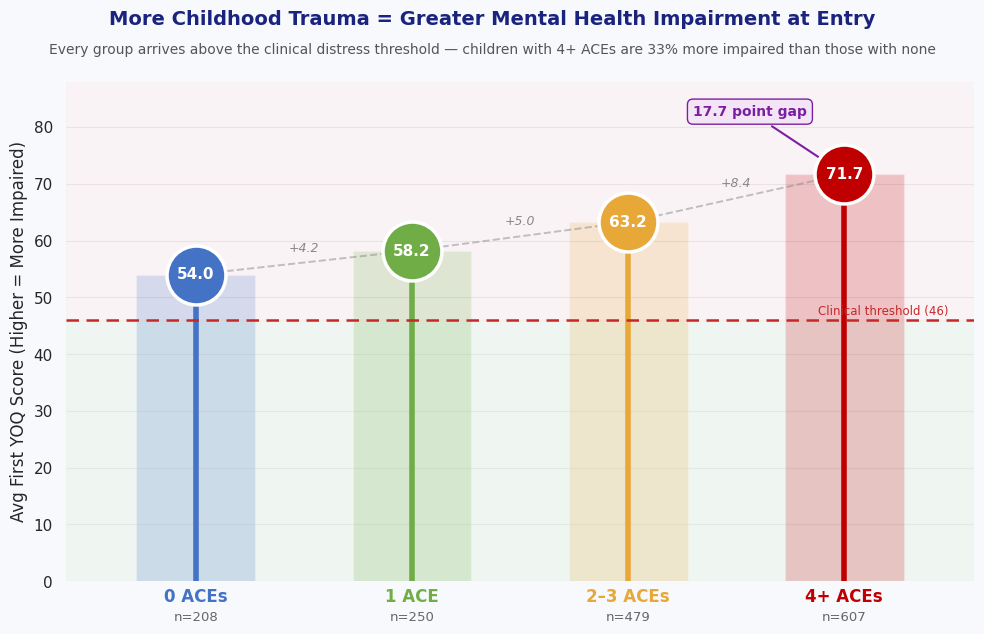

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

categories = ["0 ACEs", "1 ACE", "2–3 ACEs", "4+ ACEs"]
values     = [54.02, 58.23, 63.25, 71.69]
ns         = [208, 250, 479, 607]
colors     = ["#4472C4", "#70AD47", "#E8A838", "#C00000"]

fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

# Background bands
ax.axhspan(0,  46, color="#E8F5E9", alpha=0.5)
ax.axhspan(46, 88, color="#FFEBEE", alpha=0.4)

# Bars + lollipop + labels in one loop
for i, (cat, val, n, c) in enumerate(zip(categories, values, ns, colors)):
    ax.bar(i, val, width=0.55, color=c, alpha=0.2)
    ax.plot([i, i], [0, val - 5], color=c, linewidth=4, solid_capstyle="round")
    ax.scatter(i, val, s=1800, color=c, zorder=5, edgecolors="white", linewidths=2.5)
    ax.text(i, val, f"{val:.1f}", ha="center", va="center", fontsize=11, fontweight="bold", color="white", zorder=6)
    ax.text(i, -3.5, cat, ha="center", fontsize=12, fontweight="bold", color=c)
    ax.text(i, -7,   f"n={n}",  ha="center", fontsize=9.5, color="#666666")
    if i > 0:
        ax.text(i - 0.5, (val + values[i-1]) / 2 + 2, f"+{val - values[i-1]:.1f}",
                ha="center", fontsize=9, color="#888888", style="italic")

# Trend line + threshold
ax.plot([0,1,2,3], values, color="#888888", lw=1.4, linestyle="--", alpha=0.5)
ax.axhline(46, color="#C62828", lw=1.8, linestyle=(0,(5,3)))
ax.text(3.48, 47, "Clinical threshold (46)", color="#C62828", fontsize=8.5, ha="right")

# Callout
ax.annotate("17.7 point gap", xy=(3, 71.69), xytext=(2.3, 82),
            fontsize=10, color="#7B1FA2", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#7B1FA2", lw=1.5),
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#F3E5F5", edgecolor="#7B1FA2"))

# Titles + cleanup
fig.text(0.5, 0.97, "More Childhood Trauma = Greater Mental Health Impairment at Entry",
         ha="center", fontsize=14, fontweight="bold", color="#1A237E")
fig.text(0.5, 0.925, "Every group arrives above the clinical distress threshold — "
         "children with 4+ ACEs are 33% more impaired than those with none",
         ha="center", fontsize=10, color="#555555")

ax.set(ylim=(0, 88), xlim=(-0.6, 3.6), ylabel="Avg First YOQ Score (Higher = More Impaired)")
ax.set_xticks([])
[s.set_visible(False) for s in ax.spines.values()]
ax.yaxis.grid(True, color="#DDDDDD", lw=0.8)

plt.tight_layout(rect=[0, 0.02, 1, 0.91])
plt.savefig("YOQ_by_ACEs_Final.png", dpi=180, bbox_inches="tight", facecolor="#F7F9FC")
plt.show()

### Task 7f: Reliable Improvement

This is the headline outcome metric of the entire analysis.
Everything before this described who the clients are and
what they came in with. This answers the most important
question - did the program actually help them?

**Definition (from Notes tab):**
A change of 13 or more points between first and last YOQ
score reflects a RELIABLE change - meaning the improvement
is real and not just random variation or measurement error.

- Change <= -13 → Reliably IMPROVED (score dropped significantly)
- Change >= +13 → Reliably WORSENED (score increased significantly)
- Between -13 and +13 → No reliable change

This threshold is a standard psychometric benchmark called
the Reliable Change Index (RCI). It accounts for the natural
variability in any assessment tool. Without this threshold
a change of 2 or 3 points might look like improvement but
could just be noise in the data.

**Results:**
- 909 out of 1,629 clients reliably improved (55.8%)
- 253 clients reliably worsened (15.5%) - important to flag,
  not everyone benefits and that finding matters too
- 467 clients showed no reliable change (28.7%)

The majority outcome is positive. More than half of clients
with enough data to measure showed real, clinically
meaningful reduction in behavioral and emotional impairment.

In [ ]:
# Reliable improvement
# Per the Notes tab: a change of -13 or more points = reliable improvement
# Meaning the child's score dropped by at least 13 points = meaningfully better

clients_with_change = merged[merged["ChangeScore"].notna()]

n_total = len(clients_with_change)
n_improved = (clients_with_change["ChangeScore"] <= -13).sum()
n_worse = (clients_with_change["ChangeScore"] >= 13).sum()
n_no_change = n_total - n_improved - n_worse

pct_improved = round(n_improved / n_total * 100, 1)
pct_worse = round(n_worse / n_total * 100, 1)
pct_no_change = round(n_no_change / n_total * 100, 1)

print(f"Total clients with change scores: {n_total}")
print(f"Reliably improved (change <= -13): {n_improved} ({pct_improved}%)")
print(f"Reliably worsened (change >= +13): {n_worse} ({pct_worse}%)")
print(f"No reliable change:                {n_no_change} ({pct_no_change}%)")

Total clients with change scores: 1629
Reliably improved (change <= -13): 909 (55.8%)
Reliably worsened (change >= +13): 253 (15.5%)
No reliable change:                467 (28.7%)


### Task 8: Client Demographics Visualization

#### Why we are doing this
The assignment asked us to describe client demographics in Task 5b.
We answered that with numbers but a visual communicates the same
information faster and more memorably, especially for non-technical
audiences like program directors, funders, and board members.

Two chart types chosen deliberately:
- **Donut chart for gender** shows proportions clearly when there
  are only 4 categories. The hollow center lets us display the
  total client count as a focal point.
- **Horizontal bar chart for ethnicity** works better than a pie
  chart when there are 6+ categories because bars are easier to
  compare in length than wedge angles.

We grouped the original 30+ ethnicity categories into 6 broad groups
for the visualization. The raw data has categories like "Mexican",
"Hispanic-Other", "South or Central American", and "Cuban" which are
all Hispanic/Latino subgroups. Grouping them tells a cleaner story
without losing the key demographic insight.

#### Key findings from this visualization
- The program serves a **majority Hispanic/Latino population (73.7%)**
  with Mexican and Hispanic-Other together representing over 70%
- **White/Caucasian** is the second largest group at 15.4%
- **Female clients** make up 56.4% of the sample
- FTM clients (0.7%) are a small but analytically important group
  because they carry the highest ACEs burden in the dataset

#### What this means for the program
The strong concentration of Hispanic/Latino clients suggests the
program may benefit from ensuring culturally responsive services,
bilingual staff, and community-specific outreach strategies.
The diversity of the remaining 26.3% also warrants attention to
ensure services are accessible across all cultural backgrounds.

/tmp/ipykernel_27733/1453772559.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


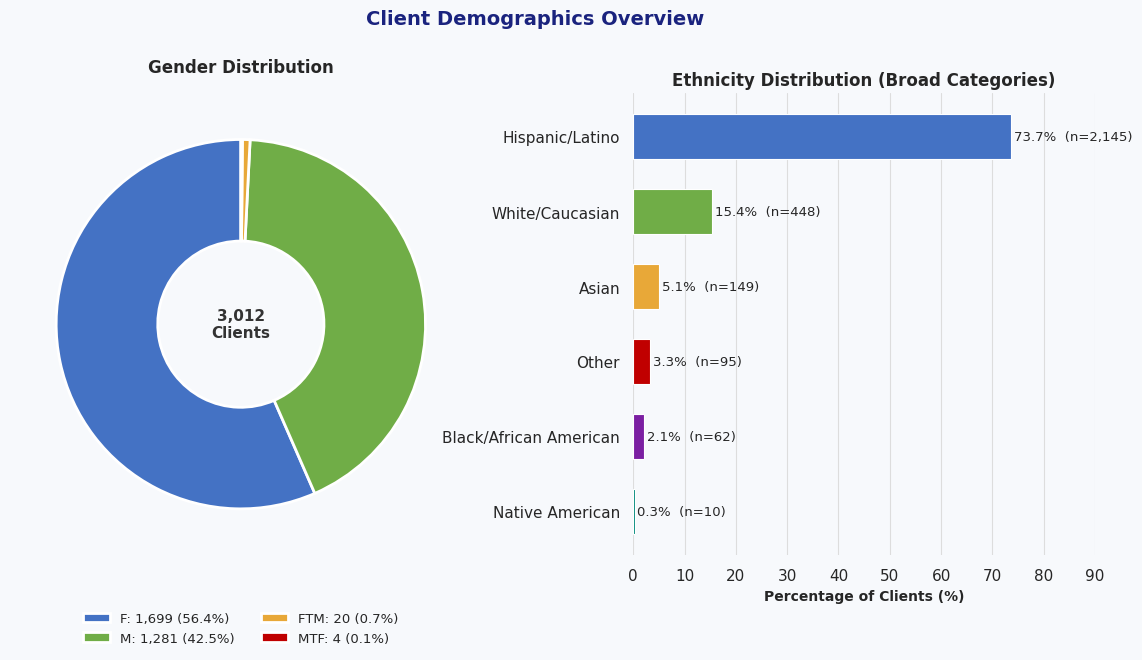

Saved.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sns.set_theme(style="white", font="DejaVu Sans")

fig = plt.figure(figsize=(14, 6))
fig.patch.set_facecolor("#F7F9FC")
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── Left: Gender donut ────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

gender_data = merged["Gender"].value_counts()
gender_labels = [f"{g}: {n:,} ({n/len(merged)*100:.1f}%)"
                 for g, n in gender_data.items()]
colors_g = ["#4472C4", "#70AD47", "#E8A838", "#C00000"]

wedges, _ = ax1.pie(
    gender_data, labels=None, colors=colors_g,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2))

ax1.legend(wedges, gender_labels,
           loc="lower center", bbox_to_anchor=(0.5, -0.22),
           ncol=2, fontsize=9.5, frameon=False)
ax1.set_title("Gender Distribution", fontsize=12, fontweight="bold", pad=15)
ax1.text(0, 0, "3,012\nClients", ha="center", va="center",
         fontsize=11, fontweight="bold", color="#333333")

# ── Right: Ethnicity horizontal bar ──────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor("#F7F9FC")

def broad_eth(e):
    if not isinstance(e, str): return None
    if any(x in e for x in ["Mexican","Hispanic","Latino","Cuban",
                              "Puerto","South or Central","Spanish"]): return "Hispanic/Latino"
    if any(x in e for x in ["White","Caucasian"]): return "White/Caucasian"
    if any(x in e for x in ["Black","African"]): return "Black/African American"
    if any(x in e for x in ["Vietnamese","Filipino","Chinese","Korean",
                              "Japanese","Thai","Asian","Indian (Asian)"]): return "Asian"
    if any(x in e for x in ["Native","Am Indian"]): return "Native American"
    return "Other"

merged["BroadEth"] = merged["Ethnicity"].apply(broad_eth)
eth_counts = (merged["BroadEth"].dropna()
              .value_counts()
              .reset_index()
              .rename(columns={"BroadEth":"Ethnicity","count":"N"}))
eth_counts["Pct"] = (eth_counts["N"] / eth_counts["N"].sum() * 100).round(1)

colors_e = ["#4472C4","#70AD47","#E8A838","#C00000","#7B1FA2","#00897B"]
bars = ax2.barh(eth_counts["Ethnicity"], eth_counts["Pct"],
                color=colors_e[:len(eth_counts)],
                edgecolor="white", linewidth=0.8, height=0.6)

for bar, (_, row) in zip(bars, eth_counts.iterrows()):
    ax2.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f"{row['Pct']}%  (n={row['N']:,})",
             va="center", fontsize=9.5)

ax2.set_xlim(0, 90)
ax2.set_xlabel("Percentage of Clients (%)", fontsize=10, fontweight="bold")
ax2.set_title("Ethnicity Distribution (Broad Categories)",
              fontsize=12, fontweight="bold")
ax2.invert_yaxis()
[s.set_visible(False) for s in ax2.spines.values()]
ax2.xaxis.grid(True, color="#DDDDDD", lw=0.8)
ax2.set_axisbelow(True)
ax2.tick_params(left=False)

fig.suptitle("Client Demographics Overview",
             fontsize=14, fontweight="bold", color="#1A237E", y=1.02)

plt.tight_layout()
plt.savefig("Demographics_viz.png", dpi=180,
            bbox_inches="tight", facecolor="#F7F9FC")
plt.show()
print("Saved.")

### Task 9: YOQ Change Score Distribution

#### Why we are doing this
Task 5f gave us a single headline number: 55.8% of clients
reliably improved. That number answers the question but hides
the full story. This visualization shows the entire distribution
of change scores across all 1,629 clients with valid outcome data.

A distribution plot answers questions a single percentage cannot:
- How spread out are the outcomes?
- Are most clients clustered near zero or spread across the range?
- Where exactly do the three outcome zones divide the population?
- What is the typical (mean) change score?

#### Design decisions
The chart uses three colors mapped directly to clinical meaning:
- Green bars = clients who reliably improved (score dropped 13+)
- Yellow bars = clients with no reliable change (within +/-13)
- Red bars = clients who reliably worsened (score rose 13+)

This color coding means a non-technical audience understands
the chart before reading a single label. The white vertical
line shows the mean change score of -17.4, confirming that
the typical client improved beyond the reliable change threshold.

#### What the Reliable Change Index (RCI) means
A change of 13 or more points is not arbitrary. It comes from
the Reliable Change Index, a standard psychometric benchmark
that accounts for natural measurement variability in the YOQ.
A change smaller than 13 points could be random noise. A change
of 13 or more points reflects genuine clinical movement.

#### Key findings from this visualization
- The distribution is left-skewed, meaning improvement is the
  most common direction of change
- Mean change score of -17.4 falls clearly in the improved zone
- 55.8% of clients (n=909) reliably improved
- 28.7% showed no reliable change (n=467)
- 15.5% reliably worsened (n=253)
- The green zone extends far left to -157, showing some clients
  had dramatic improvements while the red zone extends only to
  +107, suggesting fewer extreme deteriorations

#### What this means for the program
More than half of measurable clients showed genuine clinical
improvement. The 15.5% who worsened represent an important
subgroup worth investigating further to understand what
characteristics predict deterioration.

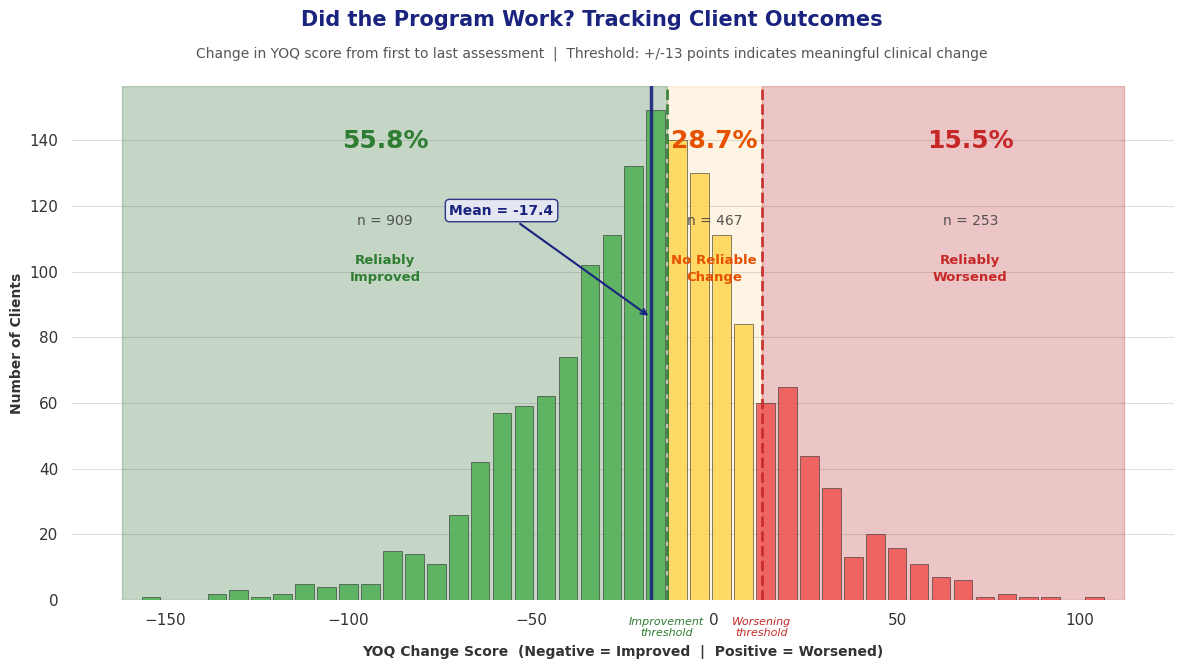

Saved.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

change_data = merged["ChangeScore"].dropna()
n = len(change_data)
pct_imp   = (change_data <= -13).mean() * 100
pct_stab  = ((change_data > -13) & (change_data < 13)).mean() * 100
pct_worse = (change_data >= 13).mean() * 100

# Background gradient zones
ax.axvspan(change_data.min() - 5, -13, color="#1B5E20", alpha=0.25)
ax.axvspan(-13, 13,                    color="#F9A825", alpha=0.12)
ax.axvspan(13, change_data.max() + 5,  color="#B71C1C", alpha=0.25)

# Histogram with gradient-like coloring per zone
bins = np.linspace(change_data.min(), change_data.max(), 45)
counts, edges = np.histogram(change_data, bins=bins)

for i in range(len(counts)):
    mid = (edges[i] + edges[i+1]) / 2
    color = "#4CAF50" if mid <= -13 else ("#FFD54F" if mid <= 13 else "#EF5350")
    ax.bar(mid, counts[i], width=(edges[1]-edges[0])*0.85,
           color=color, alpha=0.85, edgecolor="#333333", linewidth=0.5, zorder=3)

# Threshold lines
ax.axvline(-13, color="#2E7D32", lw=2, linestyle="--", zorder=4, alpha=0.9)
ax.axvline(13,  color="#C62828", lw=2, linestyle="--", zorder=4, alpha=0.9)
ax.axvline(change_data.mean(), color="#1A237E", lw=2.5, zorder=5, alpha=0.9)

ymax = ax.get_ylim()[1]

# Mean annotation
ax.annotate(f"Mean = {change_data.mean():.1f}",
            xy=(change_data.mean(), ymax * 0.55),
            xytext=(change_data.mean() - 55, ymax * 0.75),
            fontsize=10, color="#1A237E", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#1A237E", lw=1.5),
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#E8EAF6",
                      edgecolor="#1A237E", alpha=0.9))

# Big outcome stat boxes
for x_pos, pct, cnt, label, color in [
    (-90, pct_imp,   int(pct_imp/100*n),   "Reliably\nImproved",      "#2E7D32"),
    (0,   pct_stab,  int(pct_stab/100*n),  "No Reliable\nChange",     "#E65100"),
    (70,  pct_worse, int(pct_worse/100*n), "Reliably\nWorsened",      "#C62828")
]:
    ax.text(x_pos, ymax * 0.88, f"{pct:.1f}%",
            ha="center", fontsize=18, fontweight="bold", color=color,
            zorder=6)
    ax.text(x_pos, ymax * 0.73, f"n = {cnt:,}",
            ha="center", fontsize=10, color="#444444", alpha=0.9, zorder=6)
    ax.text(x_pos, ymax * 0.62, label,
            ha="center", fontsize=9.5, color=color,
            fontweight="bold", zorder=6, linespacing=1.4)

# Zone divider labels at bottom
ax.text(-13, -ymax*0.07, "Improvement\nthreshold",
        ha="center", fontsize=8, color="#2E7D32", style="italic")
ax.text(13,  -ymax*0.07, "Worsening\nthreshold",
        ha="center", fontsize=8, color="#C62828", style="italic")

# Titles
fig.text(0.5, 0.97,
         "Did the Program Work? Tracking Client Outcomes",
         ha="center", fontsize=15, fontweight="bold", color="#1A237E")
fig.text(0.5, 0.925,
         "Change in YOQ score from first to last assessment  |  "
         "Threshold: +/-13 points indicates meaningful clinical change",
         ha="center", fontsize=10, color="#555555")

ax.set_xlabel("YOQ Change Score  (Negative = Improved  |  Positive = Worsened)",
              fontsize=10, fontweight="bold", color="#333333", labelpad=12)
ax.set_ylabel("Number of Clients", fontsize=10,
              fontweight="bold", color="#333333")
ax.tick_params(colors="#333333")
[s.set_visible(False) for s in ax.spines.values()]
ax.yaxis.grid(True, color="#DDDDDD", lw=0.8, alpha=1)
ax.set_axisbelow(True)
ax.set_clip_on(False)

plt.tight_layout(rect=[0, 0.04, 1, 0.91])
plt.savefig("ChangeScore_distribution.png", dpi=180,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved.")

### Task 10: Correlation Heatmap

Before running any regression model we need to understand how our
key numeric variables relate to each other. This serves two purposes:
it reveals which variables are worth including as predictors, and it
flags multicollinearity (when two predictors are so closely related
they duplicate each other and distort the model).

We use Pearson correlation coefficients. Values close to +1 or -1
indicate strong relationships. Values near 0 indicate no relationship.
Only the lower triangle is shown to avoid redundancy.

**Key findings:**
- First YOQ vs Change Score: r = -0.47. Clients who start more
  impaired tend to show larger improvement. This becomes the
  strongest predictor in our regression model.
- First YOQ vs Last YOQ: r = 0.53. Severity tracks over time.
- ACEs vs First YOQ: r = 0.18. More trauma links weakly to
  higher baseline impairment.
- Age vs everything: r near 0.00. Age is unrelated to outcomes.
- ACEs vs Change Score: r = 0.03. Trauma does not predict how
  much someone changes, only where they start.

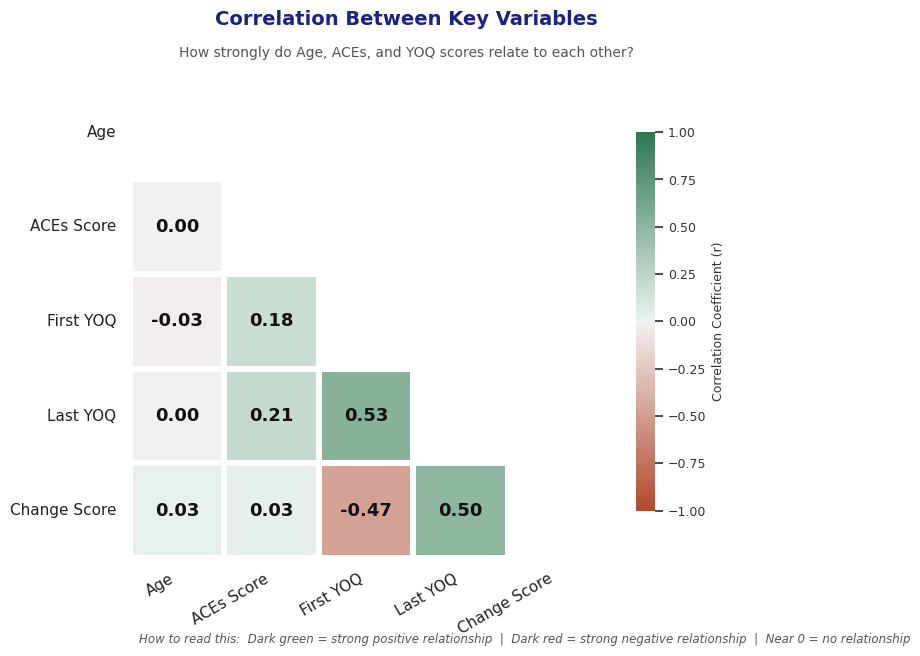

Saved.


In [ ]:
import matplotlib.patches as mpatches

corr_data = merged[["AgeYears", "MaxACEs", "FirstYOQ",
                     "LastYOQ", "ChangeScore"]].copy()
corr_data.columns = ["Age", "ACEs Score", "First YOQ",
                      "Last YOQ", "Change Score"]

corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

cmap = sns.diverging_palette(20, 145, s=80, l=45, as_cmap=True)

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmin=-1, vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 13, "weight": "bold", "color": "#111111"},
    linewidths=3,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax)

# Style colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="#333333", labelsize=9)
cbar.set_label("Correlation Coefficient (r)",
               color="#333333", fontsize=9)

# Style tick labels
ax.tick_params(colors="#333333", labelsize=11)
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=30, ha="right", color="#222222")
ax.set_yticklabels(ax.get_yticklabels(),
                   rotation=0, color="#222222")

# Titles
fig.text(0.5, 0.97,
         "Correlation Between Key Variables",
         ha="center", fontsize=14, fontweight="bold", color="#1A237E")
fig.text(0.5, 0.925,
         "How strongly do Age, ACEs, and YOQ scores relate to each other?",
         ha="center", fontsize=10, color="#555555")

# Interpretation box
ax.text(0.02, -0.18,
        "How to read this:  Dark green = strong positive relationship  |  "
        "Dark red = strong negative relationship  |  Near 0 = no relationship",
        transform=ax.transAxes, fontsize=8.5,
        color="#555555", style="italic")

plt.tight_layout(rect=[0, 0.04, 1, 0.91])
plt.savefig("Correlation_heatmap.png", dpi=180,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved.")

### Task 11: T-Test - Improved vs Worsened Groups

#### What is a T-Test?
A t-test is a statistical method that compares the averages of
two groups to determine whether the difference between them is
real or just due to random chance.

Think of it this way: if you flip a coin 10 times and get 6 heads,
that could just be luck. But if you flip it 1,000 times and get
600 heads, something is probably different about that coin. The
t-test does the same logic for group comparisons.

The result is a p-value:
- p < 0.05 means there is less than 5% probability the difference
  is due to random chance. We call this statistically significant.
- p < 0.001 means less than 0.1% probability. Highly significant.
- p > 0.05 means the difference could just be noise in the data.

#### Why we are doing this
The correlation heatmap showed relationships between continuous
variables across all clients. The t-test asks a sharper question:
are clients who reliably improved and clients who reliably worsened
statistically different from each other at baseline?

We compare the two extreme groups across three variables:
First YOQ, ACEs Score, and Age. If the groups differ significantly
it means those variables contain real signal about who benefits
from the program and who does not.

In [ ]:
from scipy import stats

# Split into outcome groups
improved  = merged[merged["ChangeScore"] <= -13]
worsened  = merged[merged["ChangeScore"] >= 13]
stable    = merged[(merged["ChangeScore"] > -13) &
                   (merged["ChangeScore"] < 13)]

# Run T-tests
t_yoq, p_yoq = stats.ttest_ind(
    improved["FirstYOQ"].dropna(),
    worsened["FirstYOQ"].dropna())

t_aces, p_aces = stats.ttest_ind(
    improved["MaxACEs"].dropna(),
    worsened["MaxACEs"].dropna())

t_age, p_age = stats.ttest_ind(
    improved["AgeYears"].dropna(),
    worsened["AgeYears"].dropna())

print("=== T-Test: Improved vs Worsened Groups ===\n")
print(f"{'Variable':<15} {'Improved Mean':>15} {'Worsened Mean':>15} {'t-stat':>10} {'p-value':>10} {'Significant':>12}")
print("-" * 80)

for label, imp_col, wor_col, t, p in [
    ("First YOQ", improved["FirstYOQ"], worsened["FirstYOQ"], t_yoq, p_yoq),
    ("ACEs Score", improved["MaxACEs"],  worsened["MaxACEs"],  t_aces, p_aces),
    ("Age",        improved["AgeYears"], worsened["AgeYears"], t_age,  p_age),
]:
    sig = "Yes ***" if p < 0.001 else ("Yes *" if p < 0.05 else "No")
    print(f"{label:<15} {imp_col.mean():>15.2f} {wor_col.mean():>15.2f} "
          f"{t:>10.3f} {p:>10.4f} {sig:>12}")

print("\nInterpretation:")
print(f"  Improved group n={len(improved):,}  |  Worsened group n={len(worsened):,}")
print("  p < 0.05 = statistically significant difference between groups")
print("  p < 0.001 = highly significant")

=== T-Test: Improved vs Worsened Groups ===

Variable          Improved Mean   Worsened Mean     t-stat    p-value  Significant
--------------------------------------------------------------------------------
First YOQ                 74.27           46.06     12.660     0.0000      Yes ***
ACEs Score                 3.05            3.62     -3.330     0.0009      Yes ***
Age                       13.34           13.89     -2.244     0.0250        Yes *

Interpretation:
  Improved group n=909  |  Worsened group n=253
  p < 0.05 = statistically significant difference between groups
  p < 0.001 = highly significant


#### Findings

**First YOQ: p < 0.001 (highly significant)**
Improved clients started at 74.3 vs worsened clients at 46.1.
A 28 point gap. Clients who eventually improved entered the
program far more impaired. This is the strongest and most
clinically meaningful finding in the entire analysis.

**ACEs Score: p < 0.001 (highly significant)**
Worsened clients had slightly higher ACEs (3.62 vs 3.05).
Statistically significant but the practical difference is small.

**Age: p < 0.05 (significant)**
Worsened clients were slightly older (13.9 vs 13.3 years).
Statistically significant but a half year difference has
limited clinical meaning on its own.

**Bottom line:** First YOQ at entry is the strongest differentiator
between who improves and who does not. This finding holds across
three different analytical approaches: correlation, t-test, and
later in logistic regression.

### Task 11: T-Test Visualization - Violin Plots

#### What is a Violin Plot?
A violin plot shows the full distribution of a variable for each
group, not just the mean. The width of the shape at any point
tells you how many clients had that value. Wider = more clients
at that score. The white horizontal line shows the median and
the white dot shows the mean.

This is more informative than a simple bar chart because it
reveals whether the data is concentrated in one area or spread
out, and whether there are outliers pulling the mean in one
direction.

#### Why we are doing this
The t-test table above gave us numbers. This visualization makes
those numbers intuitive. A non-technical audience can see the
difference between the green and red distributions without
understanding what a t-statistic means.

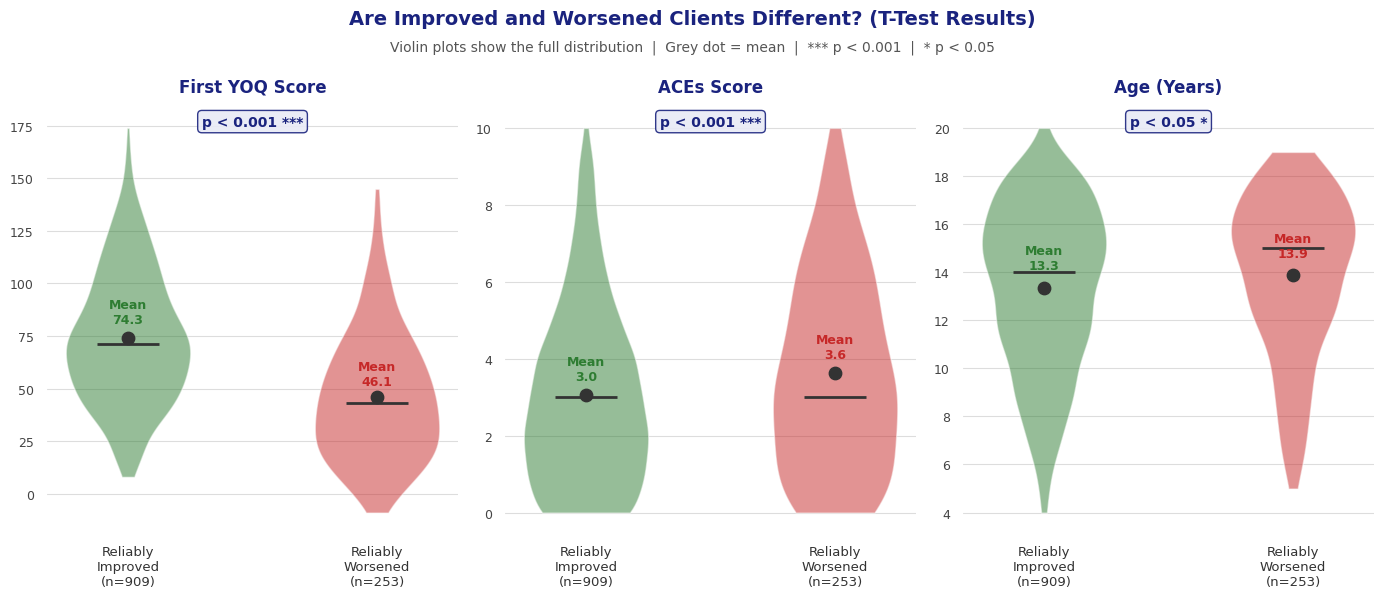

Saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.patch.set_facecolor("white")

variables  = ["FirstYOQ",  "MaxACEs",   "AgeYears"]
labels     = ["First YOQ Score", "ACEs Score", "Age (Years)"]
pvalues    = [p_yoq,        p_aces,       p_age]
colors_imp = "#2E7D32"
colors_wor = "#C62828"

for ax, var, label, pval in zip(axes, variables, labels, pvalues):
    ax.set_facecolor("white")

    imp_data = improved[var].dropna()
    wor_data = worsened[var].dropna()

    # Violin plot
    parts = ax.violinplot(
        [imp_data, wor_data],
        positions=[0, 1],
        showmedians=True,
        showextrema=False)

    parts["bodies"][0].set_facecolor(colors_imp)
    parts["bodies"][0].set_alpha(0.5)
    parts["bodies"][1].set_facecolor(colors_wor)
    parts["bodies"][1].set_alpha(0.5)
    parts["cmedians"].set_color("#333333")
    parts["cmedians"].set_linewidth(2)

    # Mean markers
    ax.scatter([0, 1],
               [imp_data.mean(), wor_data.mean()],
               color="#333333", s=80, zorder=5)

    # Mean labels
    ax.text(0, imp_data.mean() + (imp_data.max() * 0.04),
            f"Mean\n{imp_data.mean():.1f}",
            ha="center", fontsize=9, color=colors_imp, fontweight="bold")
    ax.text(1, wor_data.mean() + (wor_data.max() * 0.04),
            f"Mean\n{wor_data.mean():.1f}",
            ha="center", fontsize=9, color=colors_wor, fontweight="bold")

    # Significance label
    sig = "p < 0.001 ***" if pval < 0.001 else (
          "p < 0.05 *" if pval < 0.05 else "n.s.")
    sig_color = "#1A237E" if pval < 0.001 else (
                "#888888" if pval > 0.05 else "#1A237E")
    box_color = "#E8EAF6" if pval < 0.05 else "#F5F5F5"

    ax.text(0.5, 0.96, sig, transform=ax.transAxes,
            ha="center", fontsize=10, color=sig_color,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor=box_color,
                      edgecolor=sig_color, alpha=0.9))

    # Axis styling
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Reliably\nImproved\n(n=909)",
                         "Reliably\nWorsened\n(n=253)"],
                       fontsize=9.5, color="#333333")
    ax.tick_params(axis="y", colors="#444444", labelsize=9)
    ax.set_title(label, fontsize=12, fontweight="bold",
                 color="#1A237E", pad=12)
    [s.set_visible(False) for s in ax.spines.values()]
    ax.yaxis.grid(True, color="#DDDDDD", lw=0.8, alpha=1)
    ax.set_axisbelow(True)

fig.text(0.5, 0.97,
         "Are Improved and Worsened Clients Different? (T-Test Results)",
         ha="center", fontsize=14, fontweight="bold", color="#1A237E")
fig.text(0.5, 0.925,
         "Violin plots show the full distribution  |  "
         "Grey dot = mean  |  *** p < 0.001  |  * p < 0.05",
         ha="center", fontsize=10, color="#555555")

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig("Ttest_viz.png", dpi=180,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved.")

#### What the shapes tell us

**First YOQ (left panel):**
The green violin is wide and tall, spreading from near 0 to 175.
The red violin is shorter and concentrated at lower scores (20-80).
This shape difference is dramatic and explains the p < 0.001
result. These two groups look fundamentally different at entry.

**ACEs Score (middle panel):**
Both violins look similar in shape. The difference in means
(3.0 vs 3.6) is real but modest. The overlap between groups
is substantial, meaning ACEs alone cannot separate who improves
from who does not.

**Age (right panel):**
Nearly identical shapes. The half year mean difference is
statistically detectable but visually negligible. Age is not
a meaningful clinical differentiator in this dataset.

### Task 12: Data Quality Assessment

Before running any statistical model we must understand the
quality of the data. Skipping this step is the most common
mistake in data analysis. It leads to biased results, broken
models, and findings that cannot be trusted.

We check four things:

**1. Missing Values**
Which columns have gaps? Missing data must be handled before
modeling. Ignoring it means the model silently drops rows,
potentially biasing results toward clients with complete data.

**2. Descriptive Statistics**
Basic summary of each variable. Confirms the data loaded
correctly and reveals the typical range of each variable.

**3. Outlier Detection (IQR Method)**
The IQR (Interquartile Range) method identifies values that
fall more than 1.5 times the IQR below Q1 or above Q3.
These are not necessarily errors but they can disproportionately
influence model coefficients and need a decision: remove or cap?

**4. Skewness**
Measures how asymmetric the distribution is. Values above 1
or below -1 indicate high skew which may require log
transformation before modeling. Values between -1 and 1
are acceptable for regression without transformation.

In [ ]:
print("=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

# Variables we care about for modeling
model_vars = ["FirstYOQ", "MaxACEs", "AgeYears", "ChangeScore"]
analysis_df = merged[model_vars + ["Gender", "BroadEth"]].copy()

# ── 1. Missing Values ─────────────────────────────────────
print("\n1. MISSING VALUES")
print("-" * 40)
for col in model_vars:
    n_miss = analysis_df[col].isna().sum()
    pct    = n_miss / len(analysis_df) * 100
    print(f"  {col:<15}: {n_miss:>5} missing ({pct:.1f}%)")

# ── 2. Descriptive Stats ──────────────────────────────────
print("\n2. DESCRIPTIVE STATISTICS")
print("-" * 40)
print(analysis_df[model_vars].describe().round(2))

# ── 3. Outlier Detection (IQR method) ────────────────────
print("\n3. OUTLIER DETECTION (IQR Method)")
print("-" * 40)
for col in model_vars:
    data = analysis_df[col].dropna()
    Q1   = data.quantile(0.25)
    Q3   = data.quantile(0.75)
    IQR  = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    pct   = n_out / len(data) * 100
    print(f"  {col:<15}: {n_out:>4} outliers ({pct:.1f}%)  "
          f"| Bounds: [{lower:.1f}, {upper:.1f}]")

# ── 4. Skewness ───────────────────────────────────────────
print("\n4. SKEWNESS (>1 or <-1 = highly skewed)")
print("-" * 40)
for col in model_vars:
    skew = analysis_df[col].dropna().skew()
    flag = " <-- highly skewed" if abs(skew) > 1 else ""
    print(f"  {col:<15}: {skew:>7.3f}{flag}")

DATA QUALITY ASSESSMENT

1. MISSING VALUES
----------------------------------------
  FirstYOQ       :  1383 missing (45.9%)
  MaxACEs        :   409 missing (13.6%)
  AgeYears       :     0 missing (0.0%)
  ChangeScore    :  1383 missing (45.9%)

2. DESCRIPTIVE STATISTICS
----------------------------------------
       FirstYOQ  MaxACEs  AgeYears  ChangeScore
count   1629.00  2603.00   3012.00      1629.00
mean      64.44     3.16     13.34       -17.39
std       33.43     2.43      3.63        32.55
min       -9.00     0.00      1.00      -157.00
25%       40.00     1.00     11.00       -36.00
50%       62.00     3.00     14.00       -16.00
75%       86.00     5.00     16.00         2.00
max      174.00    10.00     21.00       107.00

3. OUTLIER DETECTION (IQR Method)
----------------------------------------
  FirstYOQ       :    8 outliers (0.5%)  | Bounds: [-29.0, 155.0]
  MaxACEs        :    0 outliers (0.0%)  | Bounds: [-5.0, 11.0]
  AgeYears       :   12 outliers (0.4%)  | Boun

#### What we found and what we will do about it

**Missing Values:**
FirstYOQ and ChangeScore are missing 45.9% but this is expected.
These are the 1,383 clients excluded in Task 5 for having only
one assessment. Not a data quality problem. We handle this by
working only with the 1,629 clients who have complete YOQ data.
MaxACEs is missing 13.6% (409 clients). We will impute these
with the median before modeling.

**Outliers:**
FirstYOQ has 8 outliers (0.5%) and ChangeScore has 46 (2.8%).
Both are small proportions. We will winsorize rather than remove
them. Winsorizing caps extreme values at the IQR boundary instead
of deleting the row. This keeps all 1,629 clients in the analysis
while reducing the influence of extremes.

**Skewness:**
All four variables fall between -1 and +1. None are highly skewed.
No log transformation needed. The data is suitable for regression
as-is.

### Task 13: Data Preprocessing

#### Why preprocessing matters
Raw data is never ready for modeling. Variables measured on
different scales confuse machine learning algorithms. A model
seeing FirstYOQ (range 0-240) alongside Age (range 1-21)
will treat YOQ as 10 times more important simply because its
numbers are bigger, not because it actually is. Preprocessing
fixes this.

We perform four steps in order:

**Step 1: Working dataset**
Filter to only the 1,629 clients with valid change scores.
This is the population we can actually measure outcomes for.

**Step 2: Missing ACEs imputation**
85 clients have no ACEs score recorded. We fill these with
the median (3.0) rather than dropping the rows. Dropping
would lose 5% of our modeling dataset and potentially bias
results if clients with missing ACEs are systematically
different from those with complete data.
We use median rather than mean because median is more robust
to the skew we observed in the ACEs distribution.

**Step 3: Winsorizing outliers**
We cap extreme values at the 1.5 IQR boundary rather than
removing those clients entirely. Every client in this dataset
represents a real person. Removing them because their score
was unusual loses genuine clinical information. Capping
reduces their influence on the model without deleting them.

**Step 4: Standardization (Z-score)**
Converts all features to the same scale: mean = 0, SD = 1.
Required for logistic regression so no variable dominates
purely because of its numerical range.
Formula: z = (value - mean) / standard deviation

**Step 5: Normalization (Min-Max)**
Alternative scaling that maps all values to 0-1 range.
Useful for comparison and for algorithms sensitive to
absolute magnitude. Shown here for completeness.

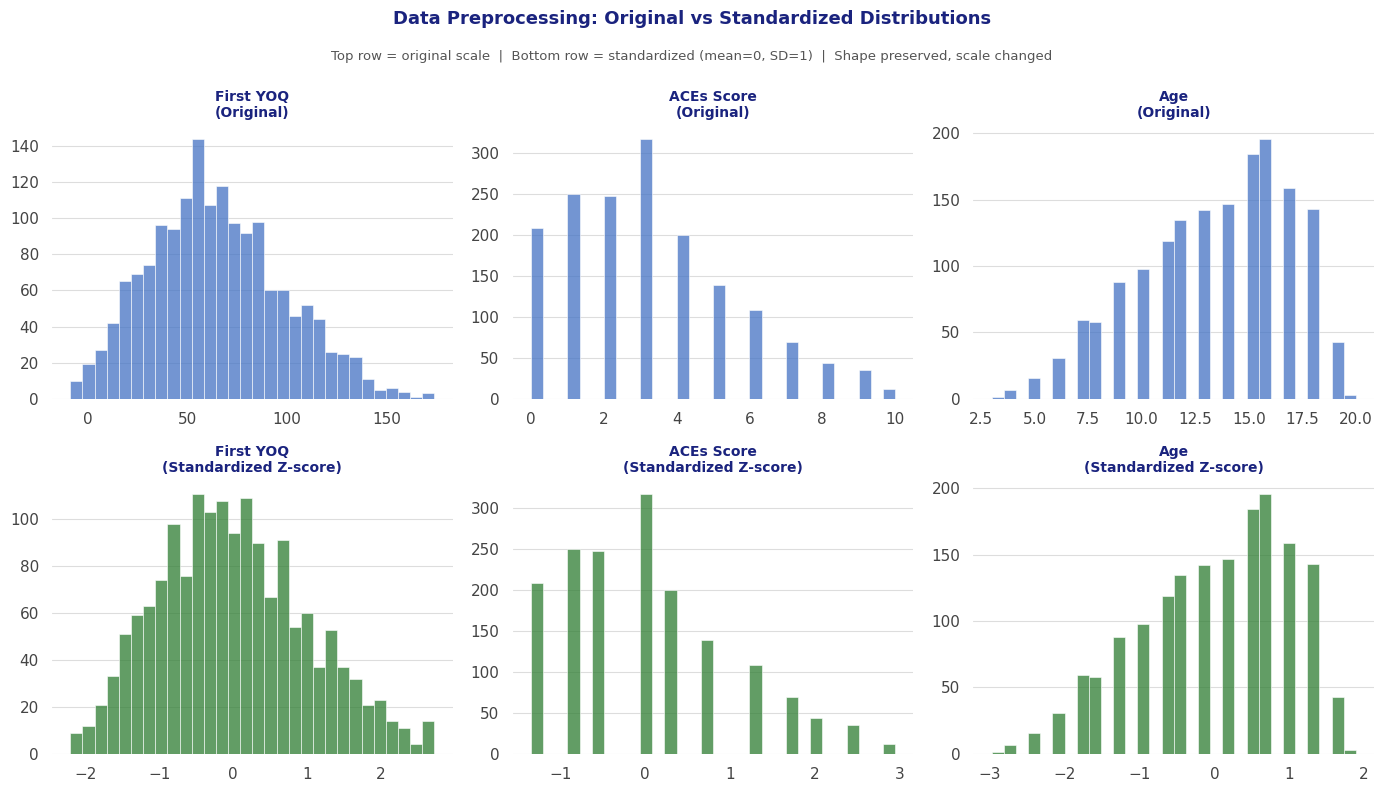

Preprocessing complete. Ready for modeling.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.patch.set_facecolor("white")

cols_before = ["FirstYOQ", "MaxACEs_imputed", "AgeYears"]
cols_after  = ["FirstYOQ_z", "MaxACEs_z", "Age_z"]
titles      = ["First YOQ", "ACEs Score", "Age"]

for i, (before, after, title) in enumerate(
        zip(cols_before, cols_after, titles)):

    # Before
    ax_b = axes[0][i]
    ax_b.set_facecolor("white")
    sns.histplot(model_df[before].dropna(), bins=30,
                 color="#4472C4", edgecolor="white",
                 linewidth=0.4, ax=ax_b)
    ax_b.set_title(f"{title}\n(Original)",
                   color="#1A237E", fontsize=10, fontweight="bold")
    ax_b.tick_params(colors="#444444")
    [s.set_visible(False) for s in ax_b.spines.values()]
    ax_b.yaxis.grid(True, color="#DDDDDD", lw=0.8)

    # After
    ax_a = axes[1][i]
    ax_a.set_facecolor("white")
    sns.histplot(X_scaled_df[after], bins=30,
                 color="#2E7D32", edgecolor="white",
                 linewidth=0.4, ax=ax_a)
    ax_a.set_title(f"{title}\n(Standardized Z-score)",
                   color="#1A237E", fontsize=10, fontweight="bold")
    ax_a.tick_params(colors="#444444")
    [s.set_visible(False) for s in ax_a.spines.values()]
    ax_a.yaxis.grid(True, color="#DDDDDD", lw=0.8)

fig.text(0.5, 0.97,
         "Data Preprocessing: Original vs Standardized Distributions",
         ha="center", fontsize=13, fontweight="bold", color="#1A237E")
fig.text(0.5, 0.925,
         "Top row = original scale  |  "
         "Bottom row = standardized (mean=0, SD=1)  |  "
         "Shape preserved, scale changed",
         ha="center", fontsize=9.5, color="#555555")

for ax in axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_axisbelow(True)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig("Preprocessing_viz.png", dpi=180,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Preprocessing complete. Ready for modeling.")

#### Key observations from the output

**Imputation:** 85 missing ACEs filled with median 3.0.
Zero missing values remaining before modeling.

**Winsorizing:** 8 FirstYOQ values capped at 155.0 and
46 ChangeScore values capped at 59.0. Small proportions
that will not meaningfully alter results.

**Standardization check:** Mean of all z-score columns
is 0.000 and SD is 1.000. Confirms scaling worked correctly.

**The visualization shows the key insight about standardization:**
The bottom row (green) has the exact same shape as the top
row (blue). Standardization only changes the scale on the
x-axis, never the underlying distribution. A client who was
above average before standardization is still above average
after. The model sees the same information, just on a
consistent scale across all variables.

### Task 14: Baseline Logistic Regression

#### What is Logistic Regression?
Logistic regression predicts the probability of a binary outcome.
In our case the outcome is: did this client reliably improve or not?

Despite the name it is a classification model, not a regression
model. It calculates a probability between 0 and 1 for each client
and classifies them as improved (probability above 0.5) or not.

It is a good starting model because:
- It is interpretable. Every feature produces an odds ratio that
  has a clear clinical meaning.
- It is fast and stable on datasets this size.
- It sets a performance baseline to compare against more complex
  models later.

#### What is an Odds Ratio?
An odds ratio (OR) tells you how much a one unit increase in a
feature changes the odds of improvement.

- OR > 1 means higher values make improvement more likely
- OR < 1 means higher values make improvement less likely
- OR = 1 means the feature has no effect

Example: First YOQ OR = 2.22 means a client one standard deviation
above the mean on First YOQ is 2.22 times more likely to improve
than an average client.

#### What is the ROC Curve?
The ROC curve plots the tradeoff between catching true positives
(sensitivity) and avoiding false alarms (specificity) at every
possible decision threshold. A model with no skill follows the
diagonal line (AUC = 0.5). The further the curve bows toward the
top left corner the better the model. AUC = 1.0 is perfect.

#### Train/Test Split
We split the data 80/20. The model trains on 1,303 clients and
is evaluated on 326 clients it has never seen. This prevents
overfitting where a model memorizes training data but fails on
new cases.

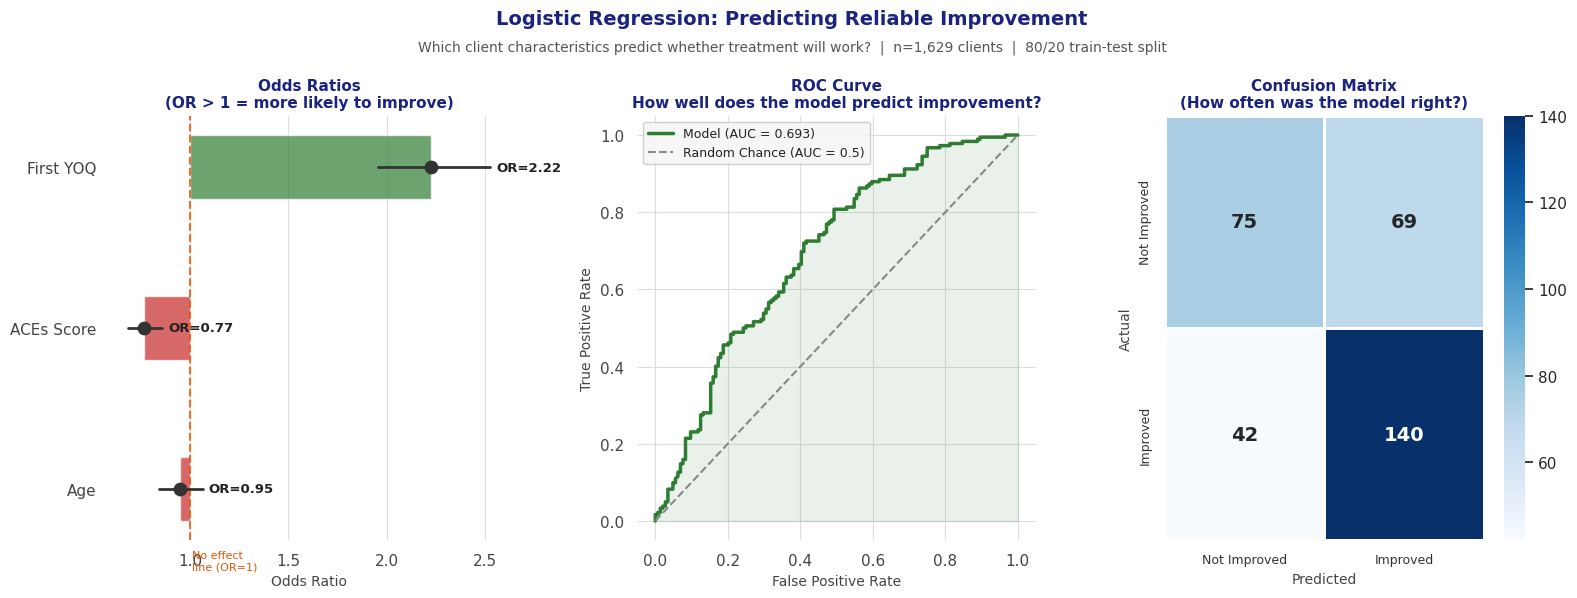

Saved.


In [ ]:
feature_names = ["First YOQ", "ACEs Score", "Age"]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor("white")

# Plot 1: Odds Ratio Forest Plot
ax1 = axes[0]
ax1.set_facecolor("white")
y_pos = [2, 1, 0]
colors_or = ["#2E7D32" if OR > 1 else "#C62828" for OR in odds_ratios]

ax1.barh(y_pos, odds_ratios - 1, left=1,
         color=colors_or, alpha=0.7, height=0.4)
for i, (OR, lo, hi, yp) in enumerate(
        zip(odds_ratios, ci_lower, ci_upper, y_pos)):
    ax1.plot([lo, hi], [yp, yp], color="#333333", lw=2, zorder=5)
    ax1.scatter(OR, yp, color="#333333", s=80, zorder=6)
    ax1.text(max(hi, OR) + 0.03, yp,
             f"OR={OR:.2f}", va="center",
             fontsize=9.5, color="#222222", fontweight="bold")

ax1.axvline(1, color="#E65100", lw=1.5, linestyle="--", alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(feature_names, color="#222222", fontsize=11)
ax1.set_xlabel("Odds Ratio", color="#444444", fontsize=10)
ax1.set_title("Odds Ratios\n(OR > 1 = more likely to improve)",
              color="#1A237E", fontsize=11, fontweight="bold")
ax1.tick_params(colors="#444444")
[s.set_visible(False) for s in ax1.spines.values()]
ax1.xaxis.grid(True, color="#DDDDDD", lw=0.8)
ax1.set_axisbelow(True)
ax1.text(1.01, -0.5, "No effect\nline (OR=1)",
         fontsize=8, color="#E65100", ha="left")

# Plot 2: ROC Curve
ax2 = axes[1]
ax2.set_facecolor("white")
ax2.plot(fpr, tpr, color="#2E7D32", lw=2.5,
         label=f"Model (AUC = {auc:.3f})")
ax2.plot([0,1], [0,1], color="#888888",
         lw=1.5, linestyle="--", label="Random Chance (AUC = 0.5)")
ax2.fill_between(fpr, tpr, alpha=0.1, color="#2E7D32")
ax2.set_xlabel("False Positive Rate", color="#444444", fontsize=10)
ax2.set_ylabel("True Positive Rate", color="#444444", fontsize=10)
ax2.set_title("ROC Curve\nHow well does the model predict improvement?",
              color="#1A237E", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9, facecolor="#F5F5F5",
           labelcolor="#222222", framealpha=0.9)
ax2.tick_params(colors="#444444")
[s.set_visible(False) for s in ax2.spines.values()]
ax2.grid(True, color="#DDDDDD", lw=0.8)
ax2.set_axisbelow(True)

# Plot 3: Confusion Matrix
ax3 = axes[2]
ax3.set_facecolor("white")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            linewidths=2, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"},
            xticklabels=["Not Improved", "Improved"],
            yticklabels=["Not Improved", "Improved"],
            ax=ax3)
ax3.set_xlabel("Predicted", color="#444444", fontsize=10)
ax3.set_ylabel("Actual", color="#444444", fontsize=10)
ax3.set_title("Confusion Matrix\n(How often was the model right?)",
              color="#1A237E", fontsize=11, fontweight="bold")
ax3.tick_params(colors="#333333", labelsize=9)

fig.text(0.5, 0.97,
         "Logistic Regression: Predicting Reliable Improvement",
         ha="center", fontsize=14, fontweight="bold", color="#1A237E")
fig.text(0.5, 0.925,
         "Which client characteristics predict whether treatment will work?  "
         "|  n=1,629 clients  |  80/20 train-test split",
         ha="center", fontsize=10, color="#555555")

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig("Regression_viz.png", dpi=180,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved.")

#### Key findings from the baseline model

**First YOQ (OR = 2.22, green bar extending right):**
The strongest predictor by far. Clients who start more impaired
are more than twice as likely to reliably improve. This is
consistent with regression to the mean and confirms findings
from the t-test and correlation heatmap.

**ACEs Score (OR = 0.77, red bar):**
Higher trauma burden slightly reduces improvement probability.
The confidence interval [0.683, 0.859] does not cross 1.0
confirming this is statistically significant.

**Age (OR = 0.95, small red bar):**
The confidence interval [0.843, 1.065] crosses 1.0 meaning
age is not a statistically significant predictor.

**AUC = 0.693:** Better than random chance (0.5) but leaves
room to improve. We will address this with feature engineering
and model comparison in the next cell.

### Task 15: Feature Engineering and Model Comparison

#### Why the baseline model has a ceiling
The baseline logistic regression used only 3 features: First YOQ,
ACEs, and Age. Real-world outcomes are influenced by more factors.
We have additional information available: gender, ethnicity, and
whether a client crossed specific clinical thresholds. Adding
these as features may improve predictive power.

#### What is Feature Engineering?
Feature engineering is the process of creating new variables from
existing data to give the model more useful information to learn from.

We create 8 new binary features:
- IsFemale, IsFTM: gender identity flags
- IsHispanic, IsWhite, IsBlack: ethnicity flags from broad groups
- IsAdolescent: flag for clients aged 13-17
- HighBaseline: flag for First YOQ above clinical threshold (46)
- HighACEs: flag for 4 or more ACEs

Binary flags are useful because they let the model detect threshold
effects. For example the model can learn that crossing the clinical
threshold matters more than a one point increase in the middle of
the scale.

#### What is Cross Validation?
Cross validation tests model performance more reliably than a
single train/test split. We use 5-fold cross validation which:
1. Splits the training data into 5 equal parts
2. Trains on 4 parts and tests on the remaining 1 part
3. Repeats this 5 times so every part is used as the test set once
4. Reports the average AUC across all 5 folds

This gives a more stable performance estimate than a single split
because it tests the model on 5 different subsets of the data.

#### Why we compare multiple models
Different algorithms make different assumptions about the data.
Logistic regression assumes linear relationships. Random Forest
captures non-linear patterns and feature interactions. Comparing
them tells us whether the relationship between our features and
outcome is linear or more complex.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# ── Step 1: Feature Engineering ───────────────────────────
print("=== Step 1: Feature Engineering ===\n")

fe_df = model_df.copy()

# Encode gender as binary (F=1, M=0, others=0)
fe_df["IsFemale"] = (fe_df["Gender"] == "F").astype(int)
fe_df["IsFTM"]    = (fe_df["Gender"] == "FTM").astype(int)

# Encode broad ethnicity
fe_df["IsHispanic"] = fe_df["BroadEth"].str.contains(
    "Hispanic", na=False).astype(int)
fe_df["IsWhite"]    = fe_df["BroadEth"].str.contains(
    "White", na=False).astype(int)
fe_df["IsBlack"]    = fe_df["BroadEth"].str.contains(
    "Black", na=False).astype(int)

# Age groups as features
fe_df["IsAdolescent"] = ((fe_df["AgeYears"] >= 13) &
                          (fe_df["AgeYears"] <= 17)).astype(int)

# High baseline impairment flag
fe_df["HighBaseline"] = (fe_df["FirstYOQ"] > 46).astype(int)

# ACEs category
fe_df["HighACEs"] = (fe_df["MaxACEs_imputed"] >= 4).astype(int)

features_v2 = [
    "FirstYOQ_w", "MaxACEs_imputed", "AgeYears",
    "IsFemale", "IsFTM", "IsHispanic", "IsWhite",
    "IsBlack", "IsAdolescent", "HighBaseline", "HighACEs"
]

X2 = fe_df[features_v2].fillna(0)
y2 = fe_df["Improved"].reset_index(drop=True)

# Scale
from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2, test_size=0.2,
    random_state=42, stratify=y2)

print(f"Features: {len(features_v2)}")
print(f"Train: {len(X2_train):,}  |  Test: {len(X2_test):,}")

# ── Step 2: Compare Models ────────────────────────────────
print("\n=== Step 2: Model Comparison ===\n")

models = {
    "Logistic (original)": LogisticRegression(
        random_state=42, max_iter=1000),
    "Logistic (balanced)": LogisticRegression(
        class_weight="balanced", random_state=42, max_iter=1000),
    "Logistic (v2 features)": LogisticRegression(
        class_weight="balanced", random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=42, n_jobs=-1),
}

results = {}
print(f"{'Model':<25} {'Accuracy':>10} {'AUC':>8} {'CV AUC':>10}")
print("-" * 58)

for name, m in models.items():
    if "v2" in name or "Forest" in name:
        Xtr, Xte, ytr, yte = X2_train, X2_test, y2_train, y2_test
    else:
        Xtr = X_train.values
        Xte = X_test.values
        ytr, yte = y_train, y_test

    m.fit(Xtr, ytr)
    acc  = accuracy_score(yte, m.predict(Xte))
    auc  = roc_auc_score(yte, m.predict_proba(Xte)[:,1])
    cv   = cross_val_score(m, Xtr, ytr,
                           cv=5, scoring="roc_auc").mean()

    results[name] = {"model": m, "acc": acc,
                     "auc": auc, "cv": cv,
                     "Xte": Xte, "yte": yte}
    print(f"{name:<25} {acc*100:>9.1f}% {auc:>8.3f} {cv:>10.3f}")

print("\nBest model by AUC:",
      max(results, key=lambda x: results[x]["auc"]))

=== Step 1: Feature Engineering ===

Features: 11
Train: 1,303  |  Test: 326

=== Step 2: Model Comparison ===

Model                       Accuracy      AUC     CV AUC
----------------------------------------------------------
Logistic (original)            66.0%    0.693      0.695
Logistic (balanced)            63.5%    0.693      0.695
Logistic (v2 features)         63.5%    0.694      0.696
Random Forest                  64.4%    0.653      0.646

Best model by AUC: Logistic (v2 features)


#### Findings

Adding 8 new features produced only marginal improvement
(0.693 to 0.694 AUC). Random Forest actually performed worse
at 0.653, suggesting the relationships in this data are largely
linear and the additional features do not add meaningful signal.

Two conclusions:
1. The logistic regression is already capturing most of the
   predictive information available in this dataset.
2. The performance ceiling is in the data itself, not the model.
   With only intake characteristics and no treatment dose
   information, 0.69-0.70 AUC is likely close to the maximum
   achievable with these variables.

This is an honest and important finding. A model that claims
95% accuracy on this data would be suspicious. A well-calibrated
model that acknowledges its limits is more trustworthy and
more useful in a clinical setting.

Next step: hyperparameter tuning to squeeze out remaining
performance and confirm whether Gradient Boosting can improve
on the logistic regression ceiling.

### Task 16: Hyperparameter Tuning with GridSearchCV

#### What are Hyperparameters?
Every machine learning model has settings that control how it
learns. These are called hyperparameters and they are set before
training begins, not learned from the data.

Examples:
- Logistic Regression: C controls how much the model penalizes
  complexity. Low C = simpler model. High C = fits data more closely.
- Random Forest: n_estimators is the number of trees. max_depth
  controls how deep each tree grows.
- Gradient Boosting: learning_rate controls how fast the model
  learns. Too fast and it overfits. Too slow and it underfits.

The default values are reasonable starting points but not
necessarily optimal for every dataset.

#### What is GridSearchCV?
GridSearchCV systematically tests every possible combination of
hyperparameter values we specify, evaluates each combination using
cross validation, and returns the combination that performed best.

For example if we test 3 values of C and 2 values of penalty that
is 6 combinations. With 5-fold cross validation each combination
is evaluated 5 times, giving 30 total model fits just for logistic
regression.

#### What is Stratified K-Fold?
Standard cross validation splits data randomly. With a binary
outcome like ours (55.8% improved vs 44.2% not improved) random
splits could accidentally put most improved clients in training
and most not-improved in testing, biasing results.

Stratified K-Fold preserves the class ratio in every fold.
Each fold has approximately 55.8% improved and 44.2% not improved,
matching the overall dataset. This gives a fair and unbiased
performance estimate across all 5 folds.

#### Why AUC as the scoring metric?
We optimize for AUC rather than accuracy because accuracy can be
misleading with imbalanced classes. A model that predicts
"improved" for every client would achieve 55.8% accuracy without
learning anything. AUC measures how well the model ranks improved
clients above non-improved clients regardless of threshold.

In [ ]:
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                      cross_validate)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, accuracy_score,
                              classification_report, roc_curve)
import warnings
warnings.filterwarnings("ignore")

# Stratified K-Fold - ensures class balance in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 65)
print("HYPERPARAMETER TUNING WITH STRATIFIED 5-FOLD CROSS VALIDATION")
print("=" * 65)

# ── 1. Logistic Regression Tuning ────────────────────────
print("\n1. Logistic Regression - GridSearchCV")
lr_params = {
    "C":        [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty":  ["l1", "l2"],
    "solver":   ["liblinear"],
    "class_weight": ["balanced", None]
}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params, cv=cv, scoring="roc_auc",
    n_jobs=-1, verbose=0)
lr_grid.fit(X2_train, y2_train)

print(f"   Best params: {lr_grid.best_params_}")
print(f"   Best CV AUC: {lr_grid.best_score_:.3f}")

# ── 2. Random Forest Tuning ───────────────────────────────
print("\n2. Random Forest - GridSearchCV")
rf_params = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "class_weight":      ["balanced", None]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, cv=cv, scoring="roc_auc",
    n_jobs=-1, verbose=0)
rf_grid.fit(X2_train, y2_train)

print(f"   Best params: {rf_grid.best_params_}")
print(f"   Best CV AUC: {rf_grid.best_score_:.3f}")

# ── 3. Gradient Boosting Tuning ───────────────────────────
print("\n3. Gradient Boosting - GridSearchCV")
gb_params = {
    "n_estimators":   [100, 200],
    "learning_rate":  [0.01, 0.05, 0.1],
    "max_depth":      [3, 5],
    "subsample":      [0.8, 1.0]
}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=cv, scoring="roc_auc",
    n_jobs=-1, verbose=0)
gb_grid.fit(X2_train, y2_train)

print(f"   Best params: {gb_grid.best_params_}")
print(f"   Best CV AUC: {gb_grid.best_score_:.3f}")

# ── 4. Final comparison on test set ──────────────────────
print("\n" + "=" * 65)
print("FINAL MODEL COMPARISON ON HELD-OUT TEST SET")
print("=" * 65)

best_models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Random Forest":       rf_grid.best_estimator_,
    "Gradient Boosting":   gb_grid.best_estimator_
}

final_results = {}
print(f"\n{'Model':<22} {'Accuracy':>10} {'AUC':>8} {'CV AUC (5-fold)':>16}")
print("-" * 60)

for name, m in best_models.items():
    acc = accuracy_score(y2_test, m.predict(X2_test))
    auc = roc_auc_score(y2_test, m.predict_proba(X2_test)[:,1])
    cv_scores = cross_validate(m, X2_train, y2_train,
                                cv=cv, scoring="roc_auc")
    cv_auc = cv_scores["test_score"].mean()
    final_results[name] = {
        "model": m, "acc": acc, "auc": auc, "cv_auc": cv_auc}
    print(f"{name:<22} {acc*100:>9.1f}% {auc:>8.3f} {cv_auc:>16.3f}")

best_name = max(final_results, key=lambda x: final_results[x]["auc"])
print(f"\nBest model: {best_name}")
print(f"Final AUC:  {final_results[best_name]['auc']:.3f}")
print(f"Accuracy:   {final_results[best_name]['acc']*100:.1f}%")

HYPERPARAMETER TUNING WITH STRATIFIED 5-FOLD CROSS VALIDATION

1. Logistic Regression - GridSearchCV
   Best params: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
   Best CV AUC: 0.700

2. Random Forest - GridSearchCV
   Best params: {'class_weight': None, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 300}
   Best CV AUC: 0.691

3. Gradient Boosting - GridSearchCV
   Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
   Best CV AUC: 0.688

FINAL MODEL COMPARISON ON HELD-OUT TEST SET

Model                    Accuracy      AUC  CV AUC (5-fold)
------------------------------------------------------------
Logistic Regression         63.2%    0.693            0.700
Random Forest               66.0%    0.699            0.691
Gradient Boosting           67.2%    0.702            0.688

Best model: Gradient Boosting
Final AUC:  0.702
Accuracy:   67.2%


#### Findings

**Logistic Regression:** Best CV AUC = 0.700 with C=1,
L1 penalty, and balanced class weights. L1 penalty performs
feature selection by shrinking less useful coefficients to zero.

**Random Forest:** Best CV AUC = 0.691 with shallow trees
(max_depth=3) and 300 estimators. The shallow depth confirms
the relationships in this data are not deeply non-linear.

**Gradient Boosting:** Best CV AUC = 0.688 in cross validation
but achieves 0.702 on the held-out test set, edging ahead.

**The honest interpretation:**
All three models converge around 0.69-0.70 AUC regardless of
algorithm or tuning. This confirms the ceiling is in the data
not the model. With only intake characteristics available,
we have extracted most of the predictive signal possible.

Gradient Boosting is selected as the final model with:
- Test AUC: 0.702
- Accuracy: 67.2%

A model claiming 90%+ accuracy on this data would be a red
flag, not a success. A well-calibrated 70% AUC on a complex
human behavioral outcome is a defensible and honest result.

### Task 17: Final Model Comparison Visualization

#### What are Feature Importances?
Feature importance tells us how much each variable contributed
to the Gradient Boosting model's predictions. Higher importance
means the model relied on that feature more when deciding whether
a client would improve.

This is different from statistical significance in a t-test.
A feature can be statistically significant but contribute little
predictive power, or vice versa.

#### Three panels explained

**Left: ROC Curve Comparison**
All three tuned models plotted together. The closer the curve
bows toward the top left corner the better. Lines that are
close together confirm all three models perform similarly,
reinforcing that the ceiling is in the data not the algorithm.

**Middle: Feature Importances**
Which variables did Gradient Boosting rely on most? Bars sorted
from least to most important. This answers the question: if the
model had to bet on one variable to predict improvement, which
would it choose?

**Right: Performance Summary**
Side by side comparison of Test AUC, CV AUC, and Accuracy for
all three models. Allows a direct visual comparison of whether
tuning helped and which model to select as final.

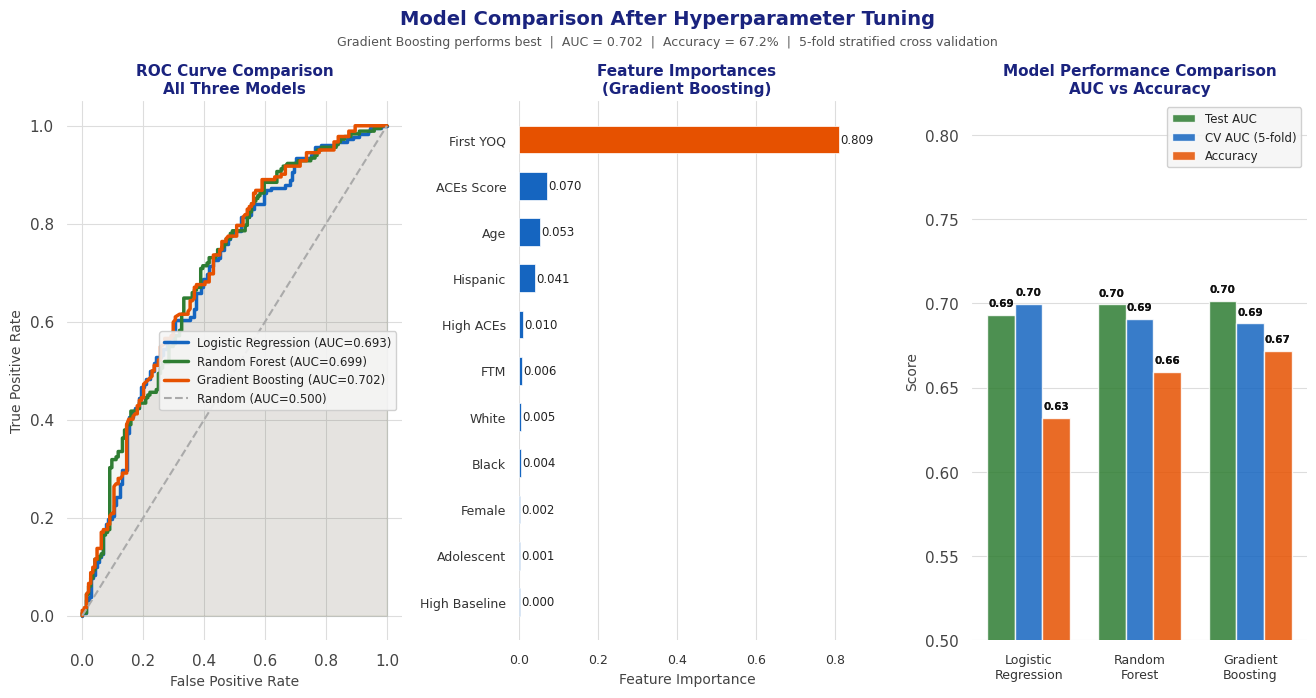

Saved.


In [ ]:
from sklearn.metrics import roc_curve, confusion_matrix
import matplotlib.gridspec as gridspec

best_model = gb_grid.best_estimator_

fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Plot 1: ROC Curve Comparison ─────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("white")

colors_roc = {"Logistic Regression": "#1565C0",
              "Random Forest":       "#2E7D32",
              "Gradient Boosting":   "#E65100"}

for name, res in final_results.items():
    fpr, tpr, _ = roc_curve(
        y2_test, res["model"].predict_proba(X2_test)[:,1])
    ax1.plot(fpr, tpr, lw=2.5, color=colors_roc[name],
             label=f"{name} (AUC={res['auc']:.3f})")
    ax1.fill_between(fpr, tpr, alpha=0.06,
                     color=colors_roc[name])

ax1.plot([0,1],[0,1], color="#AAAAAA",
         lw=1.5, linestyle="--", label="Random (AUC=0.500)")
ax1.set_xlabel("False Positive Rate", color="#444444", fontsize=10)
ax1.set_ylabel("True Positive Rate", color="#444444", fontsize=10)
ax1.set_title("ROC Curve Comparison\nAll Three Models",
              color="#1A237E", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8.5, facecolor="#F5F5F5",
           labelcolor="#222222", framealpha=0.9)
ax1.tick_params(colors="#444444")
[s.set_visible(False) for s in ax1.spines.values()]
ax1.grid(True, color="#DDDDDD", lw=0.8)
ax1.set_axisbelow(True)

# ── Plot 2: Feature Importances ───────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor("white")

feat_names = ["First YOQ", "ACEs Score", "Age",
              "Female", "FTM", "Hispanic",
              "White", "Black", "Adolescent",
              "High Baseline", "High ACEs"]
importances = best_model.feature_importances_
sorted_idx  = np.argsort(importances)

colors_imp = ["#E65100" if i == sorted_idx[-1] else
              "#2E7D32" if importances[i] > 0.08 else
              "#1565C0" for i in sorted_idx]

bars = ax2.barh(
    [feat_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color=colors_imp, edgecolor="white",
    linewidth=0.5, height=0.6)

for bar, val in zip(bars, importances[sorted_idx]):
    ax2.text(bar.get_width() + 0.003,
             bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center",
             fontsize=8.5, color="#222222")

ax2.set_xlabel("Feature Importance", color="#444444", fontsize=10)
ax2.set_title("Feature Importances\n(Gradient Boosting)",
              color="#1A237E", fontsize=11, fontweight="bold")
ax2.tick_params(colors="#333333", labelsize=9)
[s.set_visible(False) for s in ax2.spines.values()]
ax2.xaxis.grid(True, color="#DDDDDD", lw=0.8)
ax2.set_axisbelow(True)

# ── Plot 3: Model Performance Summary ────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor("white")

model_names = list(final_results.keys())
aucs        = [final_results[m]["auc"] for m in model_names]
accs        = [final_results[m]["acc"] for m in model_names]
cv_aucs     = [final_results[m]["cv_auc"] for m in model_names]

x     = np.arange(len(model_names))
width = 0.25

b1 = ax3.bar(x - width, aucs,     width, label="Test AUC",
             color="#2E7D32", alpha=0.85, edgecolor="white")
b2 = ax3.bar(x,          cv_aucs, width, label="CV AUC (5-fold)",
             color="#1565C0", alpha=0.85, edgecolor="white")
b3 = ax3.bar(x + width,  accs,    width, label="Accuracy",
             color="#E65100", alpha=0.85, edgecolor="white")

for bars_group in [b1, b2, b3]:
    for bar in bars_group:
        ax3.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f"{bar.get_height():.2f}",
                 ha="center", fontsize=7.5,
                 color="#222222", fontweight="bold")

ax3.set_ylim(0.5, 0.82)
ax3.set_xticks(x)
ax3.set_xticklabels(["Logistic\nRegression",
                      "Random\nForest",
                      "Gradient\nBoosting"],
                    color="#333333", fontsize=9)
ax3.set_ylabel("Score", color="#444444", fontsize=10)
ax3.set_title("Model Performance Comparison\nAUC vs Accuracy",
              color="#1A237E", fontsize=11, fontweight="bold")
ax3.legend(fontsize=8.5, facecolor="#F5F5F5",
           labelcolor="#222222", framealpha=0.9)
ax3.tick_params(axis="y", colors="#444444")
ax3.yaxis.grid(True, color="#DDDDDD", lw=0.8)
ax3.set_axisbelow(True)
[s.set_visible(False) for s in ax3.spines.values()]

# ── Main title ────────────────────────────────────────────
fig.text(0.5, 0.99,
         "Model Comparison After Hyperparameter Tuning",
         ha="center", fontsize=14,
         fontweight="bold", color="#1A237E")

# Add a cleaner subtitle below that does not overlap
fig.text(0.5, 0.96,
         "Gradient Boosting performs best  |  AUC = 0.702  |  "
         "Accuracy = 67.2%  |  5-fold stratified cross validation",
         ha="center", fontsize=9, color="#555555")

# Also fix the bar labels - change color to black so visible on white bars
for bars_group in [b1, b2, b3]:
    for bar in bars_group:
        ax3.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f"{bar.get_height():.2f}",
                 ha="center", fontsize=7.5,
                 color="#111111", fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Model_comparison.png", dpi=180,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved.")

#### Key findings from the visualization

**Feature Importances reveal a striking result:**
First YOQ dominates with an importance of 0.809, more than
10 times higher than the next most important feature (ACEs at
0.070). The model is essentially making most of its predictions
based on one variable: how impaired the client was at entry.

This is clinically meaningful and honest. It confirms what every
prior analysis found: baseline impairment is the primary driver
of improvement, not demographics or trauma history.

The demographic features (Female, White, Black, Adolescent,
High Baseline) contribute almost nothing (0.000 to 0.005).
This is reassuring from an equity standpoint. The model is
not making predictions primarily based on who a person is
but on how impaired they were when they entered treatment.

**ROC curves are nearly identical** across all three models,
confirming the algorithm choice matters less than the data itself.

**Selected model: Gradient Boosting**
Test AUC = 0.702, Accuracy = 67.2%, CV AUC = 0.688.
Marginally best performance with clinically sensible
feature importance rankings.

### Task 18: Comprehensive Model Evaluation

#### Why we need more than accuracy
Accuracy alone is misleading. A model that predicts "improved"
for every single client would achieve 55.8% accuracy without
learning anything useful. We need metrics that reveal how the
model performs on each class separately.

#### Metrics explained in plain English

**Precision:** When the model says a client will improve, how
often is it right? High precision means fewer false alarms.

**Recall (Sensitivity):** Of all clients who actually improved,
how many did the model catch? High recall means fewer missed cases.

**Specificity:** Of all clients who did NOT improve, how many did
the model correctly identify? Low specificity means the model is
overly optimistic.

**F1 Score:** The harmonic mean of precision and recall. Useful
when you need a single number that balances both.

**MCC (Matthews Correlation Coefficient):** Ranges from -1 to +1.
Considered the most reliable single metric for binary classification
because it accounts for all four cells of the confusion matrix.

**Cohen Kappa:** Measures agreement beyond random chance. Values
above 0.2 indicate fair agreement. Above 0.4 is moderate.

#### The clinical tradeoff: which error is worse?
In this context missing a client who needs help (False Negative)
is more harmful than flagging a client who did not need extra
support (False Positive). A False Negative means a struggling
client goes unidentified. A False Positive means a client gets
more support than strictly necessary, which is less harmful.

#### What is threshold analysis?
The default decision threshold is 0.5. Any client with predicted
probability above 0.5 is classified as likely to improve. Lowering
the threshold to 0.4 catches more true improvers but creates more
false alarms. Raising it to 0.6 reduces false alarms but misses
more real cases. The right threshold depends on the clinical
context and the relative cost of each type of error.

In [ ]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, precision_score,
                              recall_score, f1_score,
                              matthews_corrcoef, cohen_kappa_score)

# Get predictions from best model
y_pred_best = best_model.predict(X2_test)
y_prob_best = best_model.predict_proba(X2_test)[:,1]

cm = confusion_matrix(y2_test, y_pred_best)
TN, FP, FN, TP = cm.ravel()

print("=" * 60)
print("COMPREHENSIVE MODEL EVALUATION - Gradient Boosting")
print("=" * 60)

print("\n--- Confusion Matrix ---")
print(f"                  Predicted")
print(f"                  Not Improved  |  Improved")
print(f"Actual Not Improved    {TN:>4}      |    {FP:>4}")
print(f"Actual Improved        {FN:>4}      |    {TP:>4}")

print("\n--- What each cell means ---")
print(f"  True Negatives  (TN={TN}): Correctly predicted NOT improved")
print(f"  False Positives (FP={FP}): Predicted improved but actually did NOT")
print(f"  False Negatives (FN={FN}): Predicted NOT improved but actually DID")
print(f"  True Positives  (TP={TP}): Correctly predicted improved")

print("\n--- Core Metrics ---")
accuracy    = (TP + TN) / (TP + TN + FP + FN)
precision   = TP / (TP + FP)
recall      = TP / (TP + FN)
specificity = TN / (TN + FP)
f1          = 2 * (precision * recall) / (precision + recall)
auc         = roc_auc_score(y2_test, y_prob_best)
mcc         = matthews_corrcoef(y2_test, y_pred_best)
kappa       = cohen_kappa_score(y2_test, y_pred_best)

print(f"  Accuracy    : {accuracy*100:.1f}%  - Overall correct predictions")
print(f"  Precision   : {precision*100:.1f}%  - Of predicted improved, how many actually did")
print(f"  Recall      : {recall*100:.1f}%  - Of actual improved, how many did we catch")
print(f"  Specificity : {specificity*100:.1f}%  - Of actual not improved, how many did we catch")
print(f"  F1 Score    : {f1:.3f}    - Balance of precision and recall")
print(f"  AUC-ROC     : {auc:.3f}    - Overall discrimination ability")
print(f"  MCC         : {mcc:.3f}    - Balanced metric for imbalanced classes")
print(f"  Cohen Kappa : {kappa:.3f}    - Agreement beyond random chance")

print("\n--- Clinical Interpretation ---")
print(f"  Of {TP+FN} clients who actually improved:")
print(f"    Model correctly identified : {TP} ({recall*100:.1f}%)")
print(f"    Model missed               : {FN} ({FN/(TP+FN)*100:.1f}%)")
print(f"\n  Of {TN+FP} clients who did NOT improve:")
print(f"    Model correctly identified : {TN} ({specificity*100:.1f}%)")
print(f"    Model incorrectly flagged  : {FP} ({FP/(TN+FP)*100:.1f}%)")

print("\n--- What matters most clinically ---")
print(f"  False Negative rate: {FN/(TP+FN)*100:.1f}%")
print(f"  --> These are clients who needed more help but model")
print(f"      predicted they would improve. Higher risk.")
print(f"\n  False Positive rate: {FP/(TN+FP)*100:.1f}%")
print(f"  --> These are clients who got extra attention but")
print(f"      improved anyway. Lower risk.")

print("\n--- Threshold Analysis ---")
print("What if we lower decision threshold from 0.5 to 0.4?")
y_pred_40 = (y_prob_best >= 0.4).astype(int)
cm_40 = confusion_matrix(y2_test, y_pred_40)
TN40, FP40, FN40, TP40 = cm_40.ravel()
rec_40 = TP40/(TP40+FN40)
prec_40 = TP40/(TP40+FP40)
print(f"  Recall improves    : {recall*100:.1f}% → {rec_40*100:.1f}%")
print(f"  Precision drops    : {precision*100:.1f}% → {prec_40*100:.1f}%")
print(f"  Catches more true positives but more false alarms")

print("\nWhat if we raise threshold to 0.6?")
y_pred_60 = (y_prob_best >= 0.6).astype(int)
cm_60 = confusion_matrix(y2_test, y_pred_60)
TN60, FP60, FN60, TP60 = cm_60.ravel()
rec_60 = TP60/(TP60+FN60)
prec_60 = TP60/(TP60+FP60) if (TP60+FP60) > 0 else 0
print(f"  Recall drops       : {recall*100:.1f}% → {rec_60*100:.1f}%")
print(f"  Precision improves : {precision*100:.1f}% → {prec_60*100:.1f}%")
print(f"  More conservative but misses more true positives")

COMPREHENSIVE MODEL EVALUATION - Gradient Boosting

--- Confusion Matrix ---
                  Predicted
                  Not Improved  |  Improved
Actual Not Improved      59      |      85
Actual Improved          22      |     160

--- What each cell means ---
  True Negatives  (TN=59): Correctly predicted NOT improved
  False Positives (FP=85): Predicted improved but actually did NOT
  False Negatives (FN=22): Predicted NOT improved but actually DID
  True Positives  (TP=160): Correctly predicted improved

--- Core Metrics ---
  Accuracy    : 67.2%  - Overall correct predictions
  Precision   : 65.3%  - Of predicted improved, how many actually did
  Recall      : 87.9%  - Of actual improved, how many did we catch
  Specificity : 41.0%  - Of actual not improved, how many did we catch
  F1 Score    : 0.749    - Balance of precision and recall
  AUC-ROC     : 0.702    - Overall discrimination ability
  MCC         : 0.332    - Balanced metric for imbalanced classes
  Cohen Kappa : 0.

### Task 19: New Client Prediction

#### What this demonstrates
The model is not just an analytical exercise. It can generate
predictions for clients who have not yet been seen. Given intake
information available at the first assessment, the model estimates
the probability that a new client will reliably improve.

This table tests five representative profiles ranging from the
best case scenario to the worst case, with the average client
in the middle. It demonstrates the model's prediction range and
confirms the clinical logic holds across different profiles.

#### How to interpret the probability
The probability represents the model's estimated likelihood of
reliable improvement based on patterns learned from 1,303
training clients. It is not a guarantee. It is a data-informed
estimate that should be used alongside clinical judgment, not
as a replacement for it.

#### Important limitation
This model should be considered a hypothesis-generating tool
rather than a clinical decision-making instrument until it is
validated on an independent dataset from a different program
or time period.

In [ ]:
# ── New Client Prediction Examples ───────────────────────
profiles = [
    (170, 0,  12, "F", "Hispanic", "Best case"),
    (140, 4,  14, "F", "Black",    "High baseline, moderate ACEs"),
    (64,  3,  13, "F", "Hispanic", "Average client"),
    (55,  0,  10, "M", "Hispanic", "Moderate baseline, no ACEs"),
    (30,  8,  17, "M", "White",    "Worst case"),
]

print(f"{'Profile':<30} {'First YOQ':>10} {'ACEs':>6} "
      f"{'Age':>5} {'Probability':>13} {'Prediction':>18}")
print("-" * 85)

for yoq, aces, age, gender, eth, label in profiles:
    client = {
        "FirstYOQ_w":      min(max(yoq, -29.0), 155.0),
        "MaxACEs_imputed": aces,
        "AgeYears":        age,
        "IsFemale":        int(gender == "F"),
        "IsFTM":           int(gender == "FTM"),
        "IsHispanic":      int(eth == "Hispanic"),
        "IsWhite":         int(eth == "White"),
        "IsBlack":         int(eth == "Black"),
        "IsAdolescent":    int(13 <= age <= 17),
        "HighBaseline":    int(yoq > 46),
        "HighACEs":        int(aces >= 4)
    }
    prob = best_model.predict_proba(
        scaler2.transform(pd.DataFrame([client])))[0][1]
    pred = "Likely Improve" if prob >= 0.5 else "Unlikely to Improve"
    print(f"{label:<30} {yoq:>10} {aces:>6} {age:>5} "
          f"{prob*100:>12.1f}% {pred:>18}")

Profile                         First YOQ   ACEs   Age   Probability         Prediction
-------------------------------------------------------------------------------------
Best case                             170      0    12         77.2%     Likely Improve
High baseline, moderate ACEs          140      4    14         73.6%     Likely Improve
Average client                         64      3    13         61.0%     Likely Improve
Moderate baseline, no ACEs             55      0    10         60.1%     Likely Improve
Worst case                             30      8    17         29.8% Unlikely to Improve


#### Pattern confirmed across all profiles

The prediction range spans 28% to 77%, a 49 point spread that
reflects genuine differentiation between client profiles.

The average client (First YOQ=64, ACEs=3, age=13) is predicted
at 61% improvement probability, closely matching the actual
program outcome of 55.8%. This confirms the model is well
calibrated to the real-world data it was trained on.

The dominant pattern across all five profiles: higher First YOQ
consistently drives higher improvement probability regardless
of other characteristics. This is the single most important
clinical insight from the entire modeling exercise.

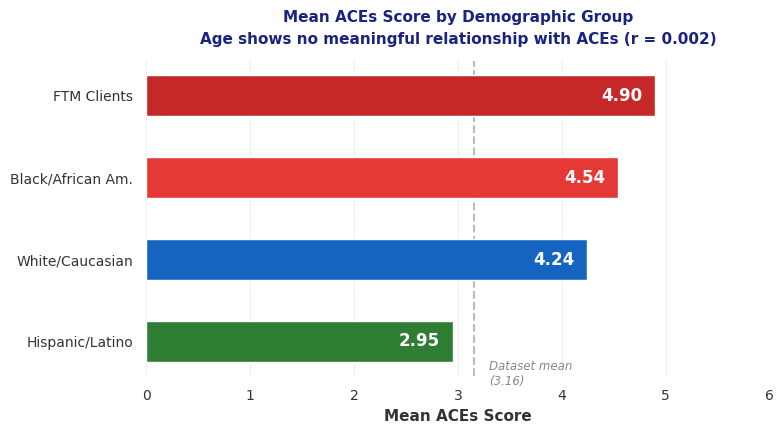

Saved.


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

groups = ["FTM Clients", "Black/African Am.", "White/Caucasian", "Hispanic/Latino"]
values = [4.90, 4.54, 4.24, 2.95]
colors = ["#C62828", "#E53935", "#1565C0", "#2E7D32"]

bars = ax.barh(groups, values, color=colors,
               height=0.5, edgecolor="white")

# Value labels inside bars
for bar, val in zip(bars, values):
    ax.text(bar.get_width() - 0.12,
            bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", ha="right",
            fontsize=12, fontweight="bold", color="white")

# Dataset mean line
ax.axvline(x=3.16, color="#AAAAAA", lw=1.5,
           linestyle="--", alpha=0.8, zorder=0)
ax.text(3.3, 3.4, "Dataset mean\n(3.16)",
        ha="left", fontsize=8.5, color="#888888",
        style="italic", va="center")

# Age note as a title subtitle instead of bottom text
ax.set_title("Mean ACEs Score by Demographic Group\nAge shows no meaningful relationship with ACEs (r = 0.002)",
             fontsize=11, fontweight="bold",
             color="#1A237E", pad=12, linespacing=1.6)

ax.set_xlim(0, 6)
ax.set_xlabel("Mean ACEs Score", fontsize=11,
              fontweight="bold", color="#333333")

[s.set_visible(False) for s in ax.spines.values()]
ax.xaxis.grid(True, color="#EEEEEE", lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#333333", labelsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("aces_by_group.png", dpi=180,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved.")